<a href="https://colab.research.google.com/github/BuruhArloji/PythonDataScienceHandbook/blob/master/Forecast_SKU_Canonical_Pipeline_V4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales 2025 SKU Real vs Edit Visualization

Notebook ini fokus ke satu tujuan: melihat dampak penyamaan SKU terhadap trend `CF` di `Sales 2025`.

Rule alignment:
- BIG 1625 / 1.625L -> BIG 1L terbaru
- BIG 3100 / 3.1L -> BIG 3L terbaru
- BIG 400ml dengan flavour sama -> SKU 400ml terbaru
- BIG Nipis 350ml -> deskripsi terbaru, SKU tetap sama
- VOLT 200ml -> SKU/deskripsi 24-pack terbaru
- Jika SKU 12-pack diarahkan ke 24-pack, `CF Edit = CF Real / 2`

In [ ]:
# Memuat library utama dan menyiapkan opsi tampilan dataframe/chart.

# Mengimpor modul bawaan Python untuk manipulasi path, regex, dan file zip.
from pathlib import Path
import re
import zipfile

# Mengimpor library utama untuk komputasi numerik (NumPy) dan manipulasi data (Pandas).
import numpy as np
import pandas as pd

# Mencoba mengimpor Plotly untuk visualisasi interaktif.
try:
    import plotly.express as px
except ModuleNotFoundError:
    # Mengabaikan error jika Plotly tidak terinstal.
    px = None

# Mencoba mengimpor Matplotlib untuk visualisasi statis dan pemformatan sumbu (axis).
try:
    import matplotlib.pyplot as plt
    from matplotlib.ticker import FuncFormatter
except ModuleNotFoundError:
    plt = None
    FuncFormatter = None

# Mengatur tampilan Pandas agar dapat menampilkan hingga 120 kolom dan memperlebar tampilan tabel.
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

## 1. Source File

Notebook ini hanya memakai file dari Google Drive. Ubah path di bawah kalau lokasi file di Drive berbeda.

In [ ]:
# Menentukan lokasi file dashboard di Google Drive dan memastikan file Excel dapat dibaca.

# Mendefinisikan lokasi absolut file di Google Drive.
DRIVE_SALES_FILE = Path("/content/drive/MyDrive/Data Sales/Indonesia Sales Dashboard 2026.xlsm")

try:
    from google.colab import drive
    # Menghubungkan (mount) Google Drive ke Colab.
    drive.mount("/content/drive")
except ModuleNotFoundError:
    # Mengabaikan error jika dijalankan di luar Colab, dan menampilkan peringatan.
    print("Run this notebook in Colab, or mount Google Drive manually before running.")

# Menghentikan program dengan error jika file tidak ditemukan.
if not DRIVE_SALES_FILE.exists():
    raise FileNotFoundError(f"File not found: {DRIVE_SALES_FILE}")

# Membaca file Excel sebagai arsip ZIP untuk memvalidasi isinya.
with zipfile.ZipFile(DRIVE_SALES_FILE) as zf:
    # Memastikan file tersebut adalah dokumen Office yang valid (bukan file rusak/corrupt).
    if "[Content_Types].xml" not in zf.namelist():
        raise ValueError(f"Not a readable Excel workbook: {DRIVE_SALES_FILE}")

# Menetapkan file untuk digunakan dan menampilkan konfirmasi.
SALES_FILE = DRIVE_SALES_FILE
print("Using:", SALES_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using: /content/drive/MyDrive/Data Sales/Indonesia Sales Dashboard 2026.xlsm


## 2. Load Data

Chart hanya memakai `Sales 2025`. `Sales 2026` dipakai sebagai acuan SKU terbaru.

In [ ]:
# Membaca sheet Sales 2025 sebagai data utama dan Sales 2026 sebagai acuan SKU terbaru.

sales25 = pd.read_excel(SALES_FILE, sheet_name="Sales 2025", engine="openpyxl")
sales26 = pd.read_excel(SALES_FILE, sheet_name="Sales 2026", engine="openpyxl")

print("Sales 2025:", sales25.shape)
print("Sales 2026 reference:", sales26.shape)
display(sales25.head(3))

Sales 2025: (20354, 36)
Sales 2026 reference: (18561, 37)


,ROW 2,Year,Month,Day,Channel Group,Branch,Channel,Region,Cust Code,Customer Name,District,Brand,Format,Flavor,Short Item Description (Edit),Item Code (Edited),Box Content,ID Sales,CU,CF,imp_paquetevta,imp_dscto,imp_cobrarvta,imp_impuesto2,imp_netovta,Date,Month2,Channel Group2,Distribution Point,Region_Cust Group,Trading Terms,Net Sales (Adjusted),List Expense,Column1,Item Code (Real),Short Item Description (Edit).1
0,1.0,2025,January,2,CEDIS,FACTORY,RETAIL,GREATER JAKARTA,413970,WARUNG STEAK & SHAKE_JATIWARINGIN ...,BEKASI,BIG,1.625,LIME,BIG LIME NRP 1Lt x6,523884,6,NaN,1.625,5,328500.0,0.0,328500.0,32554.054,295945.946,2025-01-02,1,FACTORY SALES,FACTORY,FACTORY SALES,0.0,295945.946,NaN,FXC,523417,BIG LIME NRP 1625 ML 6
1,2.0,2025,January,2,CEDIS,FACTORY,RETAIL,GREATER JAKARTA,414031,WAROENG STEAK & SHAKE_RAWAMANGUN ...,JAKARTA TIMUR,BIG,1.625,LIME,BIG LIME NRP 1Lt x6,523884,6,NaN,1.950,6,394200.0,0.0,394200.0,39064.865,355135.135,2025-01-02,1,FACTORY SALES,FACTORY,FACTORY SALES,0.0,355135.135,NaN,FXC,523417,BIG LIME NRP 1625 ML 6
2,3.0,2025,January,2,CEDIS,FACTORY,RETAIL,GREATER JAKARTA,414033,WAROENG STEAK & SHAKE_KALIMALANG ...,JAKARTA TIMUR,BIG,1.625,LIME,BIG LIME NRP 1Lt x6,523884,6,NaN,1.300,4,262800.0,0.0,262800.0,26043.243,236756.757,2025-01-02,1,FACTORY SALES,FACTORY,FACTORY SALES,0.0,236756.757,NaN,FXC,523417,BIG LIME NRP 1625 ML 6


## 3. Clean Real SKU

In [ ]:
# Membersihkan kolom SKU real, format, flavor, dan membuat Group Key untuk proses alignment.

def clean_text(value):
    # Mengubah teks menjadi huruf kapital dan menghapus spasi ganda atau berlebih.
    if pd.isna(value):
        return ""
    value = str(value).strip().upper()
    return re.sub(r"\s+", " ", value)


def clean_code(value):
    # Membersihkan format kode, khususnya menghapus akhiran '.0' jika terbaca sebagai float.
    if pd.isna(value):
        return ""
    value = str(value).strip()
    return value[:-2] if value.endswith(".0") else value


def group_key(brand, flavor, fmt):
    # Mengelompokkan SKU ke dalam kategori spesifik berdasarkan Brand, Flavor, dan Format (ukuran).
    brand = clean_text(brand)
    flavor = clean_text(flavor)
    if pd.isna(fmt):
        return ""
    fmt = float(fmt)

    # Menggunakan np.isclose untuk mengatasi masalah presisi angka desimal (float) saat membandingkan ukuran.
    if brand == "BIG" and "NIPIS" in flavor and np.isclose(fmt, 0.35):
        return "BIG_NIPIS_350"
    if brand == "BIG" and np.isclose(fmt, 0.4):
        return "BIG_400"
    if brand == "BIG" and (np.isclose(fmt, 1.625) or np.isclose(fmt, 1.0)):
        return "BIG_1L"
    if brand == "BIG" and (np.isclose(fmt, 3.1) or np.isclose(fmt, 3.0)):
        return "BIG_3L"
    if brand == "VOLT" and np.isclose(fmt, 0.2):
        return "VOLT_200_24"
    return ""


# Membuat DataFrame 'actual' baru dengan menerapkan fungsi pembersihan pada kolom-kolom yang relevan.
actual = pd.DataFrame({
    "Date": pd.to_datetime(sales25["Date"], errors="coerce"),
    "Channel Group": sales25["Channel Group"],
    "Branch": sales25["Branch"],
    "Channel": sales25["Channel"],
    "Cust Code": sales25["Cust Code"].map(clean_code),
    "Customer Name": sales25["Customer Name"],
    "Brand": sales25["Brand"].map(clean_text),
    "Flavor": sales25["Flavor"].map(clean_text),
    "Format": pd.to_numeric(sales25["Format"], errors="coerce"),
    "Box Content": sales25["Box Content"].map(clean_code),
    "CF": pd.to_numeric(sales25["CF"], errors="coerce").fillna(0),
    "Item Code Real": sales25["Item Code (Real)"].map(clean_code),
    "Short Item Description Real": sales25["Short Item Description (Edit).1"].map(clean_text),
})

# Menghapus baris yang tidak memiliki data tanggal (invalid date).
actual = actual.dropna(subset=["Date"]).copy()

# Membuat kolom 'Month' yang berisi tanggal awal dari bulan transaksi tersebut.
actual["Month"] = actual["Date"].dt.to_period("M").dt.to_timestamp()

# Menerapkan fungsi group_key ke seluruh baris data menggunakan list comprehension.
actual["Group Key"] = [group_key(b, f, s) for b, f, s in zip(actual["Brand"], actual["Flavor"], actual["Format"])]

# Membuat kolom 'SKU Real' dengan menggabungkan kode item dan deskripsi sebagai identifier unik.
actual["SKU Real"] = actual["Item Code Real"] + " | " + actual["Short Item Description Real"]

# Menampilkan 10 baris pertama dari DataFrame yang sudah dibersihkan.
display(actual.head(10))

,Date,Channel Group,Branch,Channel,Cust Code,Customer Name,Brand,Flavor,Format,Box Content,CF,Item Code Real,Short Item Description Real,Month,Group Key,SKU Real
0,2025-01-02,CEDIS,FACTORY,RETAIL,413970,WARUNG STEAK & SHAKE_JATIWARINGIN ...,BIG,LIME,1.625,6,5,523417,BIG LIME NRP 1625 ML 6,2025-01-01,BIG_1L,523417 | BIG LIME NRP 1625 ML 6
1,2025-01-02,CEDIS,FACTORY,RETAIL,414031,WAROENG STEAK & SHAKE_RAWAMANGUN ...,BIG,LIME,1.625,6,6,523417,BIG LIME NRP 1625 ML 6,2025-01-01,BIG_1L,523417 | BIG LIME NRP 1625 ML 6
2,2025-01-02,CEDIS,FACTORY,RETAIL,414033,WAROENG STEAK & SHAKE_KALIMALANG ...,BIG,LIME,1.625,6,4,523417,BIG LIME NRP 1625 ML 6,2025-01-01,BIG_1L,523417 | BIG LIME NRP 1625 ML 6
3,2025-01-02,CEDIS,FACTORY,WHOLESALE,48261,PURNAMA ...,BIG,LIME,1.625,6,30,523417,BIG LIME NRP 1625 ML 6,2025-01-01,BIG_1L,523417 | BIG LIME NRP 1625 ML 6
4,2025-01-02,CEDIS,FACTORY,WHOLESALE,117507,TOKO S3 ...,BIG,COLA,3.100,6,10,500189,BIG COLA 3100ML X6,2025-01-01,BIG_3L,500189 | BIG COLA 3100ML X6
5,2025-01-02,CEDIS,FACTORY,WHOLESALE,117507,TOKO S3 ...,BIG,STRAWBERRY,3.100,6,15,500776,BIG STRAWBERRY 3100ML X6,2025-01-01,BIG_3L,500776 | BIG STRAWBERRY 3100ML X6
6,2025-01-02,CEDIS,FACTORY,WHOLESALE,332936,MERY ...,BIG,STRAWBERRY,3.100,6,25,500776,BIG STRAWBERRY 3100ML X6,2025-01-01,BIG_3L,500776 | BIG STRAWBERRY 3100ML X6
7,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG,COLA,0.400,12,264,500040,BIG COLA 400ML X12,2025-01-01,BIG_400,500040 | BIG COLA 400ML X12
8,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG,LIME,0.400,12,264,523410,BIG LIME NRP 400 ML 12,2025-01-01,BIG_400,523410 | BIG LIME NRP 400 ML 12
9,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG,STRAWBERRY,0.400,12,264,523414,BIG SBRRY NRP 400 ML 12,2025-01-01,BIG_400,523414 | BIG SBRRY NRP 400 ML 12


## 4. Build Latest SKU Reference

Reference diambil dari `Sales 2026`, lalu dipilih row terbaru per Brand + Flavor + Group Key. Untuk VOLT, reference dibatasi ke `Box Content = 24`.

### 4.1. Upload and Cleaning Sales 2026

In [ ]:
# Mengambil dan membersihkan data mentah dari sheet Sales 2026.

ref = pd.DataFrame({
    # Mengonversi tanggal, baris error akan menjadi NaT.
    "Reference Date": pd.to_datetime(sales26["fecha_liquidacion"], errors="coerce"),
    "Brand": sales26["desc_marca"].map(clean_text),
    "Flavor": sales26["desc_sabor"].map(clean_text),
    "Format": pd.to_numeric(sales26["desc_formato"], errors="coerce"),
    "Box Content": sales26["cant_contenido"].map(clean_code),
    "CF": pd.to_numeric(sales26["CF"], errors="coerce").fillna(0),
    "Item Code Edit": sales26["cod_articulo"].map(clean_code),
    "Short Item Description Edit": sales26["desc_articulo_corto"].map(clean_text),
})

# Menghapus baris yang tidak memiliki tanggal referensi valid.
ref = ref.dropna(subset=["Reference Date"]).copy()

In [ ]:
# Membuat kunci pengelompokan dan membuang data yang tidak sesuai kriteria.

# Menerapkan fungsi group_key untuk standarisasi kategori produk.
ref["Group Key"] = [group_key(b, f, s) for b, f, s in zip(ref["Brand"], ref["Flavor"], ref["Format"])]

# Membuang data yang tidak masuk ke dalam kategori Group Key yang sudah ditentukan.
ref = ref[ref["Group Key"] != ""].copy()

# Filter khusus: Jika Group Key adalah "VOLT_200_24", pastikan isi box-nya adalah 24.
ref = ref[(ref["Group Key"] != "VOLT_200_24") | (ref["Box Content"] == "24")]

In [ ]:
# Menyusun tabel acuan akhir yang berisi SKU versi paling baru.

sku_reference = (
    # Mengurutkan data. Reference Date dan CF diurutkan menurun (False) agar data terbaru berada di atas.
    ref.sort_values(["Brand", "Flavor", "Group Key", "Reference Date", "CF"], ascending=[True, True, True, False, False])

    # Menghapus duplikat berdasarkan Brand, Flavor, dan Group Key.
    # Karena data terbaru ada di atas (berkat sort_values), keep='first' (default) akan menyimpan SKU yang paling update.
    .drop_duplicates(["Brand", "Flavor", "Group Key"])

    # Memilih hanya kolom-kolom yang diperlukan untuk tabel referensi.
    [[
        "Brand", "Flavor", "Group Key", "Reference Date",
        "Item Code Edit", "Short Item Description Edit", "Format", "Box Content",
    ]]

    # Mengganti nama kolom agar tidak tertukar dengan data aktual (Sales 2025).
    .rename(columns={"Format": "Reference Format", "Box Content": "Reference Box Content"})
)

# Menampilkan hasil tabel referensi SKU yang sudah jadi.
display(sku_reference.sort_values(["Brand", "Group Key", "Flavor"]))

,Brand,Flavor,Group Key,Reference Date,Item Code Edit,Short Item Description Edit,Reference Format,Reference Box Content
18495,BIG,COLA,BIG_1L,2026-08-15,523869,BIG COLA NRP 1LT X 6,1.00,6
18555,BIG,LIME,BIG_1L,2026-08-15,523884,BIG LIME NRP 1LT X6,1.00,6
18556,BIG,NIPIS DAN MADU LIME HONEY,BIG_1L,2026-08-15,524374,BIG NIPIS & MADU 1000ML 6,1.00,6
18390,BIG,STRAWBERRY,BIG_1L,2026-08-14,523885,BIG STRAWBERRY NRP 1LT X 6,1.00,6
18487,BIG,COLA,BIG_3L,2026-08-15,523804,BIG COLA NRP 3LT X 6,3.00,6
18509,BIG,LIME,BIG_3L,2026-08-15,523806,BIG LIME NRP 3LT X6,3.00,6
7165,BIG,ORANGE,BIG_3L,2026-03-30,524443,BIG OGE NRP 3100 ML 6,3.10,6
18515,BIG,STRAWBERRY,BIG_3L,2026-08-15,523805,BIG STRAWBERRY NRP 3LT X6,3.00,6
18523,BIG,COLA,BIG_400,2026-08-15,500040,BIG COLA 400ML X12,0.40,12
18524,BIG,LIME,BIG_400,2026-08-15,523410,BIG LIME NRP 400 ML 12,0.40,12


## 5. Apply SKU Edit

In [ ]:
# LEFT JOIN data aktual dan acuan SKU berdasarkan Brand, Flavor, dan Group Key.
aligned = actual.merge(sku_reference, on=["Brand", "Flavor", "Group Key"], how="left")

# Mengecek keberadaan referensi yang valid.
has_reference = aligned["Group Key"].ne("") & aligned["Item Code Edit"].notna()

In [ ]:
# Gunakan data edit terbaru jika ada referensi, jika tidak gunakan data aktual.
aligned["Item Code Edit"] = np.where(has_reference, aligned["Item Code Edit"], aligned["Item Code Real"])

aligned["Short Item Description Edit"] = np.where(
    has_reference,
    aligned["Short Item Description Edit"],
    aligned["Short Item Description Real"],
)

In [ ]:
# ==========================================
# 5. 3. FORMAT SKU EDIT & DETEKSI PERUBAHAN
# ==========================================
# Buat format identifier gabungan 'KODE | DESKRIPSI'.
aligned["SKU Edit"] = aligned["Item Code Edit"].map(clean_code) + " | " + aligned["Short Item Description Edit"].map(clean_text)

# Tandai baris yang mengalami perubahan SKU.
aligned["Real != Edit"] = aligned["SKU Real"] != aligned["SKU Edit"]

In [ ]:
# ==========================================
# 5. 4. PENYESUAIAN CASE FACTOR (CF)
# ==========================================
aligned["CF Real"] = aligned["CF"]

# Deteksi perubahan pack dari 12 ke 24.
pack_12_to_24 = aligned["Box Content"].eq("12") & aligned["Reference Box Content"].eq("24") & aligned["Real != Edit"]

# Bagi nilai CF menjadi dua jika terjadi perubahan pack.
aligned["CF Edit"] = np.where(pack_12_to_24, aligned["CF Real"] / 2, aligned["CF Real"])
aligned["CF Adjustment"] = np.where(pack_12_to_24, "12-pack to 24-pack: CF / 2", "No CF adjustment")

In [ ]:
# ==========================================
# 5. 6. RINGKASAN OUTPUT & TAMPILAN DATA
# ==========================================
print("Rows:", len(sales_2025_visual))
print("Rows changed Real -> Edit:", int(sales_2025_visual["Real != Edit"].sum()))
print("Rows with CF / 2 adjustment:", int((sales_2025_visual["CF Adjustment"] == "12-pack to 24-pack: CF / 2").sum()))

display(sales_2025_visual.head(10))

Rows: 20354
Rows changed Real -> Edit: 6035
Rows with CF / 2 adjustment: 108


,Source Sheet,Year,Month No,Date,Channel Group,Branch,Channel,Cust Code,Customer Name,Short Item Description Real,Item Code Real,Short Item Description Edit,Item Code Edit,Format,Box Content,Reference Format,Reference Box Content,CF Real,CF Edit,CF Adjustment,Group Key,SKU Real,SKU Edit,Real != Edit,Month
0,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,RETAIL,413970,WARUNG STEAK & SHAKE_JATIWARINGIN ...,BIG LIME NRP 1625 ML 6,523417,BIG LIME NRP 1LT X6,523884,1.625,6,1.0,6,5,5.0,No CF adjustment,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,True,2025-01-01
1,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,RETAIL,414031,WAROENG STEAK & SHAKE_RAWAMANGUN ...,BIG LIME NRP 1625 ML 6,523417,BIG LIME NRP 1LT X6,523884,1.625,6,1.0,6,6,6.0,No CF adjustment,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,True,2025-01-01
2,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,RETAIL,414033,WAROENG STEAK & SHAKE_KALIMALANG ...,BIG LIME NRP 1625 ML 6,523417,BIG LIME NRP 1LT X6,523884,1.625,6,1.0,6,4,4.0,No CF adjustment,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,True,2025-01-01
3,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,WHOLESALE,48261,PURNAMA ...,BIG LIME NRP 1625 ML 6,523417,BIG LIME NRP 1LT X6,523884,1.625,6,1.0,6,30,30.0,No CF adjustment,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,True,2025-01-01
4,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,WHOLESALE,117507,TOKO S3 ...,BIG COLA 3100ML X6,500189,BIG COLA NRP 3LT X 6,523804,3.100,6,3.0,6,10,10.0,No CF adjustment,BIG_3L,500189 | BIG COLA 3100ML X6,523804 | BIG COLA NRP 3LT X 6,True,2025-01-01
5,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,WHOLESALE,117507,TOKO S3 ...,BIG STRAWBERRY 3100ML X6,500776,BIG STRAWBERRY NRP 3LT X6,523805,3.100,6,3.0,6,15,15.0,No CF adjustment,BIG_3L,500776 | BIG STRAWBERRY 3100ML X6,523805 | BIG STRAWBERRY NRP 3LT X6,True,2025-01-01
6,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,WHOLESALE,332936,MERY ...,BIG STRAWBERRY 3100ML X6,500776,BIG STRAWBERRY NRP 3LT X6,523805,3.100,6,3.0,6,25,25.0,No CF adjustment,BIG_3L,500776 | BIG STRAWBERRY 3100ML X6,523805 | BIG STRAWBERRY NRP 3LT X6,True,2025-01-01
7,Sales 2025,2025,1,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG COLA 400ML X12,500040,BIG COLA 400ML X12,500040,0.400,12,0.4,12,264,264.0,No CF adjustment,BIG_400,500040 | BIG COLA 400ML X12,500040 | BIG COLA 400ML X12,False,2025-01-01
8,Sales 2025,2025,1,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG LIME NRP 400 ML 12,523410,BIG LIME NRP 400 ML 12,523410,0.400,12,0.4,12,264,264.0,No CF adjustment,BIG_400,523410 | BIG LIME NRP 400 ML 12,523410 | BIG LIME NRP 400 ML 12,False,2025-01-01
9,Sales 2025,2025,1,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG SBRRY NRP 400 ML 12,523414,BIG SBRRY NRP 400 ML 12,523414,0.400,12,0.4,12,264,264.0,No CF adjustment,BIG_400,523414 | BIG SBRRY NRP 400 ML 12,523414 | BIG SBRRY NRP 400 ML 12,False,2025-01-01


## 6. Mapping Summary

In [ ]:
# ==========================================
# 7. 6. MAPPING SUMMARY
# ==========================================
# Meringkas pasangan SKU Real ke SKU Edit agar perubahan alignment mudah diaudit.

mapping_summary = (
    sales_2025_visual[sales_2025_visual["Real != Edit"]]
    .groupby(["Group Key", "SKU Real", "SKU Edit"], as_index=False)
    .agg(
        rows=("CF Real", "size"),
        cf_real=("CF Real", "sum"),
        cf_edit=("CF Edit", "sum"),
        cf_adjustment=("CF Adjustment", lambda s: ", ".join(sorted(set(s)))),
        first_date=("Date", "min"),
        last_date=("Date", "max"),
    )
    .sort_values(["Group Key", "SKU Real"])
)

display(mapping_summary)

,Group Key,SKU Real,SKU Edit,rows,cf_real,cf_edit,cf_adjustment,first_date,last_date
0,BIG_1L,522275 | BIG COLA 1625ML X6,523869 | BIG COLA NRP 1LT X 6,482,24078,24078.0,No CF adjustment,2025-01-02,2025-09-03
1,BIG_1L,522276 | BIG STRAWBERRY 1625ML X6,523885 | BIG STRAWBERRY NRP 1LT X 6,82,3249,3249.0,No CF adjustment,2025-01-18,2025-04-29
2,BIG_1L,522277 | BIG LIME 1625ML X6,523884 | BIG LIME NRP 1LT X6,66,3245,3245.0,No CF adjustment,2025-01-17,2025-04-11
3,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,313,15287,15287.0,No CF adjustment,2025-01-02,2025-09-12
4,BIG_1L,523418 | BIG SBRRY NRP 1625 ML 6,523885 | BIG STRAWBERRY NRP 1LT X 6,317,14820,14820.0,No CF adjustment,2025-01-02,2025-09-12
5,BIG_3L,500189 | BIG COLA 3100ML X6,523804 | BIG COLA NRP 3LT X 6,1327,64906,64906.0,No CF adjustment,2025-01-02,2025-07-23
6,BIG_3L,500776 | BIG STRAWBERRY 3100ML X6,523805 | BIG STRAWBERRY NRP 3LT X6,380,22436,22436.0,No CF adjustment,2025-01-02,2025-07-01
7,BIG_3L,502036 | BIG LIME 3100ML X6,523806 | BIG LIME NRP 3LT X6,124,6161,6161.0,No CF adjustment,2025-01-02,2025-03-14
8,BIG_3L,523409 | BIG LIME NRP 3100 ML 6,523806 | BIG LIME NRP 3LT X6,480,27703,27703.0,No CF adjustment,2025-02-07,2025-11-18
9,BIG_3L,523413 | BIG SBRRY NRP 3100 ML 6,523805 | BIG STRAWBERRY NRP 3LT X6,1087,55558,55558.0,No CF adjustment,2025-02-12,2025-08-04


## 7. Sales 2026 Alignment

In [ ]:
# ==========================================
# 6. 1. SALES 2026 DATA PREPARATION
# ==========================================
actual26 = pd.DataFrame({
    "Date": pd.to_datetime(sales26["fecha_liquidacion"], errors="coerce"),
    "Channel Group": sales26["DescCanalLocal (grupo)"],
    "Branch": sales26["desc_sucursal"],
    "Channel": sales26["DescCanalLocal"],
    "Cust Code": sales26["cod_cliente"].map(clean_code),
    "Customer Name": sales26["nomb_cliente"],
    "Brand": sales26["desc_marca"].map(clean_text),
    "Flavor": sales26["desc_sabor"].map(clean_text),
    "Format": pd.to_numeric(sales26["desc_formato"], errors="coerce"),
    "Box Content": sales26["cant_contenido"].map(clean_code),
    "CF": pd.to_numeric(sales26["CF"], errors="coerce").fillna(0),
    "Item Code Real": sales26["cod_articulo"].map(clean_code),
    "Short Item Description Real": sales26["desc_articulo_corto"].map(clean_text),
})

actual26 = actual26.dropna(subset=["Date"]).copy()
actual26["Month"] = actual26["Date"].dt.to_period("M").dt.to_timestamp()

actual26["Group Key"] = [group_key(b, f, s) for b, f, s in zip(actual26["Brand"], actual26["Flavor"], actual26["Format"])]
actual26["SKU Real"] = actual26["Item Code Real"] + " | " + actual26["Short Item Description Real"]

In [ ]:
# ==========================================
# 6. 2. ALIGNMENT & SKU UPDATES
# ==========================================
aligned26 = actual26.merge(sku_reference, on=["Brand", "Flavor", "Group Key"], how="left")
has_reference26 = aligned26["Group Key"].ne("") & aligned26["Item Code Edit"].notna()

aligned26["Item Code Edit"] = np.where(has_reference26, aligned26["Item Code Edit"], aligned26["Item Code Real"])
aligned26["Short Item Description Edit"] = np.where(
    has_reference26,
    aligned26["Short Item Description Edit"],
    aligned26["Short Item Description Real"],
)

aligned26["SKU Edit"] = aligned26["Item Code Edit"].map(clean_code) + " | " + aligned26["Short Item Description Edit"].map(clean_text)
aligned26["Real != Edit"] = aligned26["SKU Real"] != aligned26["SKU Edit"]

In [ ]:
# ==========================================
# 6. 3. CF ADJUSTMENT
# ==========================================
aligned26["CF Real"] = aligned26["CF"]
pack_12_to_24_26 = aligned26["Box Content"].eq("12") & aligned26["Reference Box Content"].eq("24") & aligned26["Real != Edit"]

aligned26["CF Edit"] = np.where(pack_12_to_24_26, aligned26["CF Real"] / 2, aligned26["CF Real"])
aligned26["CF Adjustment"] = np.where(pack_12_to_24_26, "12-pack to 24-pack: CF / 2", "No CF adjustment")

In [ ]:
# ==========================================
# 6. 4. COLUMN SELECTION & METADATA
# ==========================================
sales_2026_visual = aligned26[[
    "Date", "Channel Group", "Branch", "Channel", "Cust Code", "Customer Name",
    "Short Item Description Real", "Item Code Real",
    "Short Item Description Edit", "Item Code Edit",
    "Format", "Box Content", "Reference Format", "Reference Box Content",
    "CF Real", "CF Edit", "CF Adjustment",
    "Group Key", "SKU Real", "SKU Edit", "Real != Edit",
]].copy()

sales_2026_visual.insert(0, "Source Sheet", "Sales 2026")
sales_2026_visual.insert(1, "Year", sales_2026_visual["Date"].dt.year)
sales_2026_visual.insert(2, "Month No", sales_2026_visual["Date"].dt.month)
sales_2026_visual["Month"] = sales_2026_visual["Date"].dt.to_period("M").dt.to_timestamp()

In [ ]:
# ==========================================
# 6. 5. MAPPING SUMMARY & OUTPUT
# ==========================================
mapping_summary_2026 = (
    sales_2026_visual[sales_2026_visual["Real != Edit"]]
    .groupby(["Group Key", "SKU Real", "SKU Edit"], as_index=False)
    .agg(
        rows=("CF Real", "size"),
        cf_real=("CF Real", "sum"),
        cf_edit=("CF Edit", "sum"),
        cf_adjustment=("CF Adjustment", lambda s: ", ".join(sorted(set(s)))),
        first_date=("Date", "min"),
        last_date=("Date", "max"),
    )
    .sort_values(["Group Key", "SKU Real"])
)

print("Sales 2026 rows:", len(sales_2026_visual))
print("Sales 2026 rows changed Real -> Edit:", int(sales_2026_visual["Real != Edit"].sum()))
print("Sales 2026 rows with CF / 2 adjustment:", int((sales_2026_visual["CF Adjustment"] == "12-pack to 24-pack: CF / 2").sum()))

display(mapping_summary_2026)

Sales 2026 rows: 18561
Sales 2026 rows changed Real -> Edit: 813
Sales 2026 rows with CF / 2 adjustment: 801


,Group Key,SKU Real,SKU Edit,rows,cf_real,cf_edit,cf_adjustment,first_date,last_date
0,BIG_3L,524402 | BIG COLA NRP 3100 ML 6,523804 | BIG COLA NRP 3LT X 6,7,8610,8610.0,No CF adjustment,2026-01-06,2026-03-10
1,BIG_3L,524543 | BIG SBRRY NRP 3100 ML 6,523805 | BIG STRAWBERRY NRP 3LT X6,5,6150,6150.0,No CF adjustment,2026-03-10,2026-03-11
2,VOLT_200_24,524163 | VOLT YELLOW WIT NRP 200 ML 12,524676 | VOLT YELLOW WIT NRP 200 ML 24,801,84387,42193.5,12-pack to 24-pack: CF / 2,2026-01-02,2026-07-14


## 8. Append Sales 2025 + Sales 2026

In [ ]:
# ==========================================
# 9. 8. APPEND SALES 2025 + SALES 2026
# ==========================================
# Menggabungkan data aligned 2025 dan 2026 menjadi satu dataset analisis.

append_columns = [
    "Source Sheet", "Year", "Month No", "Date",
    "Channel Group", "Branch", "Channel", "Cust Code", "Customer Name",
    "Short Item Description Real", "Item Code Real",
    "Short Item Description Edit", "Item Code Edit",
    "Format", "Box Content", "Reference Format", "Reference Box Content",
    "CF Real", "CF Edit", "CF Adjustment",
    "Group Key", "SKU Real", "SKU Edit", "Real != Edit",
]

sales_aligned_append = pd.concat(
    [
        sales_2025_visual[append_columns],
        sales_2026_visual[append_columns],
    ],
    ignore_index=True,
)
sales_aligned_append["Month"] = sales_aligned_append["Date"].dt.to_period("M").dt.to_timestamp()

print("Appended rows:", len(sales_aligned_append))
print("Sales 2025 rows:", len(sales_2025_visual))
print("Sales 2026 rows:", len(sales_2026_visual))
print("Total rows changed Real -> Edit:", int(sales_aligned_append["Real != Edit"].sum()))
display(sales_aligned_append.head(10))

Appended rows: 38915
Sales 2025 rows: 20354
Sales 2026 rows: 18561
Total rows changed Real -> Edit: 6848


,Source Sheet,Year,Month No,Date,Channel Group,Branch,Channel,Cust Code,Customer Name,Short Item Description Real,Item Code Real,Short Item Description Edit,Item Code Edit,Format,Box Content,Reference Format,Reference Box Content,CF Real,CF Edit,CF Adjustment,Group Key,SKU Real,SKU Edit,Real != Edit,Month
0,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,RETAIL,413970,WARUNG STEAK & SHAKE_JATIWARINGIN ...,BIG LIME NRP 1625 ML 6,523417,BIG LIME NRP 1LT X6,523884,1.625,6,1.0,6,5,5.0,No CF adjustment,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,True,2025-01-01
1,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,RETAIL,414031,WAROENG STEAK & SHAKE_RAWAMANGUN ...,BIG LIME NRP 1625 ML 6,523417,BIG LIME NRP 1LT X6,523884,1.625,6,1.0,6,6,6.0,No CF adjustment,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,True,2025-01-01
2,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,RETAIL,414033,WAROENG STEAK & SHAKE_KALIMALANG ...,BIG LIME NRP 1625 ML 6,523417,BIG LIME NRP 1LT X6,523884,1.625,6,1.0,6,4,4.0,No CF adjustment,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,True,2025-01-01
3,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,WHOLESALE,48261,PURNAMA ...,BIG LIME NRP 1625 ML 6,523417,BIG LIME NRP 1LT X6,523884,1.625,6,1.0,6,30,30.0,No CF adjustment,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,True,2025-01-01
4,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,WHOLESALE,117507,TOKO S3 ...,BIG COLA 3100ML X6,500189,BIG COLA NRP 3LT X 6,523804,3.100,6,3.0,6,10,10.0,No CF adjustment,BIG_3L,500189 | BIG COLA 3100ML X6,523804 | BIG COLA NRP 3LT X 6,True,2025-01-01
5,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,WHOLESALE,117507,TOKO S3 ...,BIG STRAWBERRY 3100ML X6,500776,BIG STRAWBERRY NRP 3LT X6,523805,3.100,6,3.0,6,15,15.0,No CF adjustment,BIG_3L,500776 | BIG STRAWBERRY 3100ML X6,523805 | BIG STRAWBERRY NRP 3LT X6,True,2025-01-01
6,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,WHOLESALE,332936,MERY ...,BIG STRAWBERRY 3100ML X6,500776,BIG STRAWBERRY NRP 3LT X6,523805,3.100,6,3.0,6,25,25.0,No CF adjustment,BIG_3L,500776 | BIG STRAWBERRY 3100ML X6,523805 | BIG STRAWBERRY NRP 3LT X6,True,2025-01-01
7,Sales 2025,2025,1,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG COLA 400ML X12,500040,BIG COLA 400ML X12,500040,0.400,12,0.4,12,264,264.0,No CF adjustment,BIG_400,500040 | BIG COLA 400ML X12,500040 | BIG COLA 400ML X12,False,2025-01-01
8,Sales 2025,2025,1,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG LIME NRP 400 ML 12,523410,BIG LIME NRP 400 ML 12,523410,0.400,12,0.4,12,264,264.0,No CF adjustment,BIG_400,523410 | BIG LIME NRP 400 ML 12,523410 | BIG LIME NRP 400 ML 12,False,2025-01-01
9,Sales 2025,2025,1,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG SBRRY NRP 400 ML 12,523414,BIG SBRRY NRP 400 ML 12,523414,0.400,12,0.4,12,264,264.0,No CF adjustment,BIG_400,523414 | BIG SBRRY NRP 400 ML 12,523414 | BIG SBRRY NRP 400 ML 12,False,2025-01-01


## 9. VOLT CF / 2 Check - Real vs Edit

In [ ]:
# ==========================================
# 10. 9. VOLT CF / 2 CHECK - REAL VS EDIT
# ==========================================
# Memvisualisasikan VOLT sebelum dan sesudah CF dibagi 2 untuk audit pack 12 ke 24.

keyword = "VOLT"

filtered = sales_aligned_append[
    sales_aligned_append["SKU Real"].str.contains(keyword, case=False, na=False)
    | sales_aligned_append["SKU Edit"].str.contains(keyword, case=False, na=False)
].copy()

filtered_long = pd.concat(
    [
        filtered.assign(SKU_View="Real Before CF / 2", SKU=filtered["SKU Real"], CF_View=filtered["CF Real"]),
        filtered.assign(SKU_View="Edit After CF / 2", SKU=filtered["SKU Edit"], CF_View=filtered["CF Edit"]),
    ],
    ignore_index=True,
)

filtered_monthly = (
    filtered_long
    .groupby(["Month", "SKU_View", "SKU"], as_index=False)
    .agg(CF=("CF_View", "sum"))
)

display(filtered_monthly)

if px:
    fig = px.line(
        filtered_monthly,
        x="Month",
        y="CF",
        color="SKU",
        line_dash="SKU_View",
        markers=True,
        category_orders={"SKU_View": ["Real Before CF / 2", "Edit After CF / 2"]},
        title=f"{keyword}: Real Before CF / 2 vs Edit After CF / 2",
    )
    fig.show()

,Month,SKU_View,SKU,CF
0,2025-11-01,Edit After CF / 2,524676 | VOLT YELLOW WIT NRP 200 ML 24,5.0
1,2025-11-01,Real Before CF / 2,524163 | VOLT YELLOW WIT NRP 200 ML 12,10.0
2,2025-12-01,Edit After CF / 2,524676 | VOLT YELLOW WIT NRP 200 ML 24,247.0
3,2025-12-01,Real Before CF / 2,524163 | VOLT YELLOW WIT NRP 200 ML 12,494.0
4,2026-01-01,Edit After CF / 2,524676 | VOLT YELLOW WIT NRP 200 ML 24,871.0
5,2026-01-01,Real Before CF / 2,524163 | VOLT YELLOW WIT NRP 200 ML 12,1742.0
6,2026-02-01,Edit After CF / 2,524676 | VOLT YELLOW WIT NRP 200 ML 24,8501.5
7,2026-02-01,Real Before CF / 2,524163 | VOLT YELLOW WIT NRP 200 ML 12,17003.0
8,2026-03-01,Edit After CF / 2,524676 | VOLT YELLOW WIT NRP 200 ML 24,2778.5
9,2026-03-01,Real Before CF / 2,524163 | VOLT YELLOW WIT NRP 200 ML 12,5557.0


## 10. Appended Monthly CF by SKU - Edit

In [ ]:
# ==========================================
# 11. 10. APPENDED MONTHLY CF BY SKU - EDIT
# ==========================================
# Membuat line chart bulanan berdasarkan SKU Edit setelah data 2025 dan 2026 digabung.

append_edit_monthly = sales_aligned_append.groupby(["Month", "SKU Edit"], as_index=False).agg(CF=("CF Edit", "sum"))
top_append_edit = append_edit_monthly.groupby("SKU Edit")["CF"].sum().nlargest(20).index
append_edit_top = append_edit_monthly[append_edit_monthly["SKU Edit"].isin(top_append_edit)]

if px:
    fig = px.line(append_edit_top, x="Month", y="CF", color="SKU Edit", markers=True, title="Sales 2025-2026 Monthly CF by SKU - Edit Top 20")
    fig.show()
else:
    display(append_edit_top.head(50))

## 11. Sales 2026 Monthly CF by SKU - Edit

In [ ]:
# ==========================================
# 12. 11. SALES 2026 MONTHLY CF BY SKU - EDIT
# ==========================================
# Mengecek tren 2026 saja setelah alignment SKU.

edit_monthly_2026 = sales_2026_visual.groupby(["Month", "SKU Edit"], as_index=False).agg(CF=("CF Edit", "sum"))
top_edit_2026 = edit_monthly_2026.groupby("SKU Edit")["CF"].sum().nlargest(20).index
edit_top_2026 = edit_monthly_2026[edit_monthly_2026["SKU Edit"].isin(top_edit_2026)]

if px:
    fig = px.line(edit_top_2026, x="Month", y="CF", color="SKU Edit", markers=True, title="Sales 2026 Monthly CF by SKU - Edit Top 20")
    fig.show()
else:
    display(edit_top_2026.head(50))

## 12. Distinct SKU Count: Real vs Edit

In [ ]:
# ==========================================
# 13. 12. DISTINCT SKU COUNT: REAL VS EDIT
# ==========================================
# Membandingkan jumlah SKU unik sebelum dan sesudah alignment per bulan.

distinct_monthly = (
    sales_aligned_append.groupby("Month")
    .agg(
        real_sku_count=("SKU Real", "nunique"),
        edit_sku_count=("SKU Edit", "nunique"),
        cf_real=("CF Real", "sum"),
        cf_edit=("CF Edit", "sum"),
    )
    .reset_index()
)

display(distinct_monthly)

if px:
    fig = px.line(
        distinct_monthly,
        x="Month",
        y=["real_sku_count", "edit_sku_count"],
        markers=True,
        title="Distinct SKU Count per Month: Real vs Edit - Sales 2025-2026",
    )
    fig.show()

,Month,real_sku_count,edit_sku_count,cf_real,cf_edit
0,2025-01-01,22,18,123334,123334.0
1,2025-02-01,25,19,275907,275907.0
2,2025-03-01,24,19,86549,86549.0
3,2025-04-01,24,19,77705,77705.0
4,2025-05-01,18,16,62849,62849.0
5,2025-06-01,25,19,52308,52308.0
6,2025-07-01,23,16,274960,274960.0
7,2025-08-01,18,13,311966,311966.0
8,2025-09-01,17,13,519379,519379.0
9,2025-10-01,12,12,397639,397639.0


## 13. Monthly CF by SKU - Real

In [ ]:
# ==========================================
# 14. 13. MONTHLY CF BY SKU - REAL
# ==========================================
# Menampilkan trend bulanan berdasarkan SKU Real sebagai pembanding sebelum edit.

real_monthly = sales_aligned_append.groupby(["Month", "SKU Real"], as_index=False).agg(CF=("CF Real", "sum"))
top_real = real_monthly.groupby("SKU Real")["CF"].sum().nlargest(20).index
real_top = real_monthly[real_monthly["SKU Real"].isin(top_real)]

if px:
    fig = px.line(real_top, x="Month", y="CF", color="SKU Real", markers=True, title="Sales 2025-2026 Monthly CF by SKU - Real Top 20")
    fig.show()
else:
    display(real_top.head(50))

## 14. Monthly CF by SKU - Edit

In [ ]:
# ==========================================
# 15. 14. MONTHLY CF BY SKU - EDIT
# ==========================================
# Menampilkan trend bulanan berdasarkan SKU Edit sebagai hasil setelah alignment.

edit_monthly = sales_aligned_append.groupby(["Month", "SKU Edit"], as_index=False).agg(CF=("CF Edit", "sum"))
top_edit = edit_monthly.groupby("SKU Edit")["CF"].sum().nlargest(20).index
edit_top = edit_monthly[edit_monthly["SKU Edit"].isin(top_edit)]

if px:
    fig = px.line(edit_top, x="Month", y="CF", color="SKU Edit", markers=True, title="Sales 2025-2026 Monthly CF by SKU - Edit Top 20")
    fig.show()
else:
    display(edit_top.head(50))

## 15. Sep 2026 Forecast Detail

Forecast ini memakai grain `Cust Code x SKU`, dengan baseline yang dibersihkan dari suspected promo/outlier secara konservatif.
Sebelum forecast, `Customer Name` dan `Branch` diselaraskan dulu agar 1 Cust Code hanya punya 1 nama dan 1 branch utama.

Parameter utama:
- `FORECAST_MONTH`: bulan yang akan diforecast
- `RUNRATE_MONTH`: bulan berjalan yang masih MTD
- `CF Edit`: volume yang sudah disetarakan SKU dan pack
- Forecast engine difilter hanya untuk `Channel Group = MODERN`
- Jika 1 Cust Code muncul dengan beberapa nama atau branch, pakai nama dan branch dengan jumlah transaksi/order row terbanyak
- Agustus run-rate memakai multiplier konservatif `1.5`
- Juli dianggap promo dan tidak menjadi driver utama baseline September

In [ ]:
# ==========================================
# 15. SEP 2026 FORECAST DETAIL
# ==========================================
# Menyiapkan data forecast MODERN, parameter run-rate, dan grain Customer x SKU.

# Menetapkan bulan forecast, bulan run-rate, multiplier run-rate, dan scope channel
FORECAST_MONTH = pd.Timestamp("2026-09-01")
RUNRATE_MONTH = FORECAST_MONTH - pd.DateOffset(months=1)
RUNRATE_MULTIPLIER = 1.5
FORECAST_CHANNEL_GROUP = "MODERN"
KNOWN_PROMO_MONTHS = [pd.Timestamp("2026-07-01")]

# Grain forecast: Cust Code x SKU
key_cols = [
    "Channel Group", "Branch", "Cust Code", "Customer Name",
    "Item Code Edit", "Short Item Description Edit", "SKU Edit",
]

# Filter forecast hanya untuk Channel Group MODERN
forecast_source = sales_aligned_append[
    sales_aligned_append["Channel Group"].map(clean_text).eq(FORECAST_CHANNEL_GROUP)
].copy()

# ==========================================
# 0. BRANCH OVERRIDE (BALI & PEKANBARU)
# ==========================================
# Memastikan customer area ekspansi terpetakan ke branch baru untuk konsolidasi volume historis
area_ref_2026 = sales_aligned_append[
    (sales_aligned_append['Year'] >= 2026) &
    (sales_aligned_append['Branch'].str.contains('BALI|PEKANBARU', case=False, na=False))
].copy()

bali_cust_exp = area_ref_2026[area_ref_2026['Branch'].str.contains('BALI', case=False, na=False)]['Cust Code'].unique()
pku_cust_exp = area_ref_2026[area_ref_2026['Branch'].str.contains('PEKANBARU', case=False, na=False)]['Cust Code'].unique()

forecast_source.loc[forecast_source['Cust Code'].isin(bali_cust_exp), 'Branch'] = 'LOGISTIC PROVIDER BALI'
forecast_source.loc[forecast_source['Cust Code'].isin(pku_cust_exp), 'Branch'] = 'LOGISTIC PROVIDER PEKANBARU'

# ==========================================
# 1. NORMALISASI IDENTITAS CUSTOMER
# ==========================================
# Simpan identitas asli sebelum normalisasi untuk audit/export CSV
forecast_source["Original Customer Name"] = forecast_source["Customer Name"]
forecast_source["Original Branch"] = forecast_source["Branch"]

customer_name_reference = (
    forecast_source
    .groupby(["Cust Code", "Customer Name"], as_index=False)
    .agg(order_rows=("CF Edit", "size"), cf_edit=("CF Edit", "sum"), last_order_date=("Date", "max"))
    .sort_values(["Cust Code", "order_rows", "cf_edit"], ascending=[True, False, False])
    .drop_duplicates(["Cust Code"], keep="first")
    .rename(columns={"Customer Name": "Primary Customer Name"})
)

customer_branch_reference = (
    forecast_source[forecast_source["Year"] >= 2026]
    .groupby(["Cust Code", "Branch"], as_index=False)
    .agg(order_rows=("CF Edit", "size"), cf_edit=("CF Edit", "sum"), last_order_date=("Date", "max"))
    .sort_values(["Cust Code", "order_rows", "cf_edit"], ascending=[True, False, False])
    .drop_duplicates(["Cust Code"], keep="first")
    .rename(columns={"Branch": "Primary Branch"})
)

forecast_source = forecast_source.merge(customer_name_reference[["Cust Code", "Primary Customer Name"]], on="Cust Code", how="left")
forecast_source = forecast_source.merge(customer_branch_reference[["Cust Code", "Primary Branch"]], on="Cust Code", how="left")
forecast_source["Customer Name"] = forecast_source["Primary Customer Name"].fillna(forecast_source["Customer Name"])
forecast_source["Branch"] = forecast_source["Primary Branch"].fillna(forecast_source["Branch"])
# Kolom Primary dihapus tetapi Original tetap ada
forecast_source = forecast_source.drop(columns=["Primary Customer Name", "Primary Branch"])

# ==========================================
# 2. UC FACTOR & AGREGASI BULANAN
# ==========================================
forecast_source["Format Edit"] = pd.to_numeric(forecast_source["Reference Format"], errors="coerce").fillna(pd.to_numeric(forecast_source["Format"], errors="coerce"))
forecast_source["Box Content Edit Numeric"] = pd.to_numeric(forecast_source["Reference Box Content"], errors="coerce").fillna(pd.to_numeric(forecast_source["Box Content"], errors="coerce"))
forecast_source["UC Factor"] = forecast_source["Format Edit"] * forecast_source["Box Content Edit Numeric"] / 30

uc_reference = forecast_source.groupby(key_cols, as_index=False).agg(UC_Factor=("UC Factor", "max"))

monthly_customer_sku = (
    forecast_source
    .groupby(["Month", *key_cols], as_index=False)
    .agg(CF=("CF Edit", "sum"))
)

print(f"Forecast Source Rows: {len(forecast_source)}")
print(f"Bali Customers Mapped: {len(bali_cust_exp)}")
print(f"Pekanbaru Customers Mapped: {len(pku_cust_exp)}")
display(monthly_customer_sku.head())

Forecast Source Rows: 29026
Bali Customers Mapped: 4
Pekanbaru Customers Mapped: 3


,Month,Channel Group,Branch,Cust Code,Customer Name,Item Code Edit,Short Item Description Edit,SKU Edit,CF
0,2025-01-01,MODERN,CEDIS MT SURABAYA,126139,PT.SUMBER ALFARIA TRIJAYA_SIDOARJO ...,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,80.0
1,2025-01-01,MODERN,CEDIS MT SURABAYA,126140,PT.SUMBER ALFARIA TRIJAYA_MALANG ...,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,180.0
2,2025-01-01,MODERN,CEDIS MT SURABAYA,134441,PT.SUMBER ALFARIA TRIJAYA_ JEMBER ...,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,80.0
3,2025-01-01,MODERN,CEDIS MT SURABAYA,161419,PT.INTI CAKRAWALA CITRA_SURABAYA ...,500040,BIG COLA 400ML X12,500040 | BIG COLA 400ML X12,33.0
4,2025-01-01,MODERN,CEDIS MT SURABAYA,161419,PT.INTI CAKRAWALA CITRA_SURABAYA ...,507563,BIG MANGO 3100ML X6,507563 | BIG MANGO 3100ML X6,6.0


In [ ]:
# ==========================================
# 15. SEP 2026 FORECAST DETAIL
# ==========================================
# Parameter dan data source untuk forecast MODERN.

FORECAST_MONTH = pd.Timestamp("2026-09-01")
RUNRATE_MONTH = FORECAST_MONTH - pd.DateOffset(months=1)
RUNRATE_MULTIPLIER = 1.5
FORECAST_CHANNEL_GROUP = "MODERN"
KNOWN_PROMO_MONTHS = [pd.Timestamp("2026-07-01")]

# Grain forecast: Customer x SKU
key_cols = [
    "Channel Group", "Branch", "Cust Code", "Customer Name",
    "Item Code Edit", "Short Item Description Edit", "SKU Edit",
]

# Filter data hanya untuk channel MODERN
forecast_source = sales_aligned_append[
    sales_aligned_append["Channel Group"].map(clean_text).eq(FORECAST_CHANNEL_GROUP)
].copy()

In [ ]:
# ==========================================
# 0. BRANCH OVERRIDE (BALI & PEKANBARU)
# ==========================================
# Memetakan customer area ekspansi ke branch baru untuk konsolidasi.

area_ref_2026 = sales_aligned_append[
    (sales_aligned_append['Year'] >= 2026) &
    (sales_aligned_append['Branch'].str.contains('BALI|PEKANBARU', case=False, na=False))
].copy()

bali_cust_exp = area_ref_2026[area_ref_2026['Branch'].str.contains('BALI', case=False, na=False)]['Cust Code'].unique()
pku_cust_exp = area_ref_2026[area_ref_2026['Branch'].str.contains('PEKANBARU', case=False, na=False)]['Cust Code'].unique()

forecast_source.loc[forecast_source['Cust Code'].isin(bali_cust_exp), 'Branch'] = 'LOGISTIC PROVIDER BALI'
forecast_source.loc[forecast_source['Cust Code'].isin(pku_cust_exp), 'Branch'] = 'LOGISTIC PROVIDER PEKANBARU'

In [ ]:
# ==========================================
# 1. NORMALISASI IDENTITAS CUSTOMER
# ==========================================
# Menyeragamkan nama customer dan branch menggunakan data transaksi terbanyak/terakhir.

# Menyimpan identitas asli sebelum ditimpa
forecast_source["Original Customer Name"] = forecast_source["Customer Name"]
forecast_source["Original Branch"] = forecast_source["Branch"]

customer_name_reference = (
    forecast_source
    .groupby(["Cust Code", "Customer Name"], as_index=False)
    .agg(order_rows=("CF Edit", "size"), cf_edit=("CF Edit", "sum"), last_order_date=("Date", "max"))
    .sort_values(["Cust Code", "order_rows", "cf_edit"], ascending=[True, False, False])
    .drop_duplicates(["Cust Code"], keep="first")
    .rename(columns={"Customer Name": "Primary Customer Name"})
)

customer_branch_reference = (
    forecast_source[forecast_source["Year"] >= 2026]
    .groupby(["Cust Code", "Branch"], as_index=False)
    .agg(order_rows=("CF Edit", "size"), cf_edit=("CF Edit", "sum"), last_order_date=("Date", "max"))
    .sort_values(["Cust Code", "order_rows", "cf_edit"], ascending=[True, False, False])
    .drop_duplicates(["Cust Code"], keep="first")
    .rename(columns={"Branch": "Primary Branch"})
)

forecast_source = forecast_source.merge(customer_name_reference[["Cust Code", "Primary Customer Name"]], on="Cust Code", how="left")
forecast_source = forecast_source.merge(customer_branch_reference[["Cust Code", "Primary Branch"]], on="Cust Code", how="left")

# Menerapkan hasil normalisasi
forecast_source["Customer Name"] = forecast_source["Primary Customer Name"].fillna(forecast_source["Customer Name"])
forecast_source["Branch"] = forecast_source["Primary Branch"].fillna(forecast_source["Branch"])
forecast_source = forecast_source.drop(columns=["Primary Customer Name", "Primary Branch"])

In [ ]:
# ==========================================
# 2. UC FACTOR & AGREGASI BULANAN
# ==========================================
# Menghitung Unit Case (UC) factor dan melakukan agregasi bulanan.

forecast_source["Format Edit"] = pd.to_numeric(forecast_source["Reference Format"], errors="coerce").fillna(pd.to_numeric(forecast_source["Format"], errors="coerce"))
forecast_source["Box Content Edit Numeric"] = pd.to_numeric(forecast_source["Reference Box Content"], errors="coerce").fillna(pd.to_numeric(forecast_source["Box Content"], errors="coerce"))
forecast_source["UC Factor"] = forecast_source["Format Edit"] * forecast_source["Box Content Edit Numeric"] / 30

uc_reference = forecast_source.groupby(key_cols, as_index=False).agg(UC_Factor=("UC Factor", "max"))

monthly_customer_sku = (
    forecast_source
    .groupby(["Month", *key_cols], as_index=False)
    .agg(CF=("CF Edit", "sum"))
)

print(f"Forecast Source Rows: {len(forecast_source)}")
print(f"Bali Customers Mapped: {len(bali_cust_exp)}")
print(f"Pekanbaru Customers Mapped: {len(pku_cust_exp)}")
display(monthly_customer_sku.head())

Forecast Source Rows: 29026
Bali Customers Mapped: 4
Pekanbaru Customers Mapped: 3


,Month,Channel Group,Branch,Cust Code,Customer Name,Item Code Edit,Short Item Description Edit,SKU Edit,CF
0,2025-01-01,MODERN,CEDIS MT SURABAYA,126139,PT.SUMBER ALFARIA TRIJAYA_SIDOARJO ...,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,80.0
1,2025-01-01,MODERN,CEDIS MT SURABAYA,126140,PT.SUMBER ALFARIA TRIJAYA_MALANG ...,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,180.0
2,2025-01-01,MODERN,CEDIS MT SURABAYA,134441,PT.SUMBER ALFARIA TRIJAYA_ JEMBER ...,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,80.0
3,2025-01-01,MODERN,CEDIS MT SURABAYA,161419,PT.INTI CAKRAWALA CITRA_SURABAYA ...,500040,BIG COLA 400ML X12,500040 | BIG COLA 400ML X12,33.0
4,2025-01-01,MODERN,CEDIS MT SURABAYA,161419,PT.INTI CAKRAWALA CITRA_SURABAYA ...,507563,BIG MANGO 3100ML X6,507563 | BIG MANGO 3100ML X6,6.0


## 16. Conservative Promo/Outlier Cleaning

In [ ]:
# ==========================================
# 17. 1. DATA PIVOTING & DATE PREPARATION
# ==========================================
# Menyiapkan rentang waktu dan mengubah data menjadi format lebar (wide).

forecast_input_months = pd.date_range("2026-03-01", RUNRATE_MONTH, freq="MS")
history_months = pd.date_range("2026-01-01", RUNRATE_MONTH, freq="MS")

# Membentuk satu baris per Customer x SKU, dengan bulan sebagai kolom.
wide = monthly_customer_sku.pivot_table(
    index=key_cols,
    columns="Month",
    values="CF",
    aggfunc="sum",
    fill_value=0,
).reset_index()

# Memastikan semua bulan histori tersedia di kolom (termasuk jika nilainya 0).
for month in history_months:
    if month not in wide.columns:
        wide[month] = 0

wide = wide[key_cols + list(history_months)]

In [ ]:
# ==========================================
# 17. 2. OUTLIER & PROMO CLEANING LOGIC
# ==========================================
# Fungsi untuk membersihkan anomali promo atau outlier per baris.

def clean_months(row):
    values = {m: float(row[m]) for m in history_months}
    clean = {}
    promo_flags = {}
    promo_uplift = {}

    for i, month in enumerate(history_months):
        actual = values[month]
        # Mengambil histori valid (nilai > 0) maksimal 3 bulan sebelumnya.
        previous = [clean[m] for m in history_months[max(0, i - 3):i] if clean.get(m, 0) > 0]

        if month in KNOWN_PROMO_MONTHS and actual > 0:
            # Batasi baseline dengan median bulan sebelumnya jika masuk bulan promo.
            if previous:
                med = float(np.median(previous))
                is_promo = True
                clean_value = min(actual, med)
            else:
                is_promo = True
                clean_value = actual
        elif len(previous) >= 2:
            # Deteksi outlier dengan batas 2x median atau median + 2x standar deviasi.
            med = float(np.median(previous))
            std = float(np.std(previous))
            threshold = max(med * 2.0, med + 2.0 * std)
            is_promo = med > 0 and actual >= 10 and actual > threshold
            clean_value = min(actual, med) if is_promo else actual
        else:
            is_promo = False
            clean_value = actual

        clean[month] = clean_value
        promo_flags[month] = is_promo
        promo_uplift[month] = max(0, actual - clean_value)

    # Kalkulasi run-rate Agustus menggunakan RUNRATE_MULTIPLIER.
    aug_actual = values.get(RUNRATE_MONTH, 0)
    aug_clean_mtd = clean.get(RUNRATE_MONTH, 0)
    aug_rr = aug_actual * RUNRATE_MULTIPLIER
    aug_clean_rr = aug_clean_mtd * RUNRATE_MULTIPLIER

    # Mengembalikan Series berisi nilai aktual, bersih, run-rate, dan detail anomali.
    return pd.Series({
        **{f"{m.strftime('%b')}_Actual": values[m] for m in forecast_input_months},
        **{f"{m.strftime('%b')}_Clean": (aug_clean_rr if m == RUNRATE_MONTH else clean[m]) for m in forecast_input_months},
        "Aug_MTD": aug_actual,
        "Aug_RunRate": aug_rr,
        "Aug_Clean_RunRate": aug_clean_rr,
        "Promo_Suspect_Months": int(sum(promo_flags.values())),
        "Promo_Suspect_Uplift": float(sum(promo_uplift.values())),
    })

In [ ]:
# ==========================================
# 17. 3. APPLY CLEANING & OUTPUT
# ==========================================
# Menerapkan fungsi ke setiap baris dan menggabungkan dengan kolom identitas awal.

clean_features = wide.apply(clean_months, axis=1)
forecast_base = pd.concat([wide[key_cols].reset_index(drop=True), clean_features], axis=1)

display(forecast_base.head())

,Channel Group,Branch,Cust Code,Customer Name,Item Code Edit,Short Item Description Edit,SKU Edit,Mar_Actual,Apr_Actual,May_Actual,Jun_Actual,Jul_Actual,Aug_Actual,Mar_Clean,Apr_Clean,May_Clean,Jun_Clean,Jul_Clean,Aug_Clean,Aug_MTD,Aug_RunRate,Aug_Clean_RunRate,Promo_Suspect_Months,Promo_Suspect_Uplift
0,MODERN,CEDIS MT SURABAYA,126139,PT.SUMBER ALFARIA TRIJAYA_SIDOARJO ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,5693.0,6142.0,1425.0,741.0,4875.0,3375.0,5693.0,6142.0,1425.0,741.0,1425.0,2137.5,3375.0,5062.5,2137.5,2.0,5400.0
1,MODERN,CEDIS MT SURABAYA,126139,PT.SUMBER ALFARIA TRIJAYA_SIDOARJO ...,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,MODERN,CEDIS MT SURABAYA,126139,PT.SUMBER ALFARIA TRIJAYA_SIDOARJO ...,523884,BIG LIME NRP 1LT X6,523884 | BIG LIME NRP 1LT X6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,MODERN,CEDIS MT SURABAYA,126139,PT.SUMBER ALFARIA TRIJAYA_SIDOARJO ...,523885,BIG STRAWBERRY NRP 1LT X 6,523885 | BIG STRAWBERRY NRP 1LT X 6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,MODERN,CEDIS MT SURABAYA,126139,PT.SUMBER ALFARIA TRIJAYA_SIDOARJO ...,524374,BIG NIPIS & MADU 1000ML 6,524374 | BIG NIPIS & MADU 1000ML 6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 17. Segmented Robust Forecast

In [ ]:
# ==========================================
# 18. 1. PARAMETER & FUNGSI BANTU
# ==========================================
# Mendefinisikan kolom tren dan fungsi statistik dasar (menghindari error saat data kosong).

non_promo_cols = ["Mar_Clean", "Apr_Clean", "May_Clean", "Jun_Clean", "Aug_Clean"]
recent_non_promo_cols = ["Jun_Clean", "Aug_Clean"]
inactive_3m_cols = ["Jun_Actual", "Jul_Actual", "Aug_Actual"]

def nonzero(values):
    # Menyaring array agar hanya menyisakan nilai di atas 0.
    return [float(v) for v in values if float(v) > 0]

def trimmed_mean(values):
    # Menghitung rata-rata dengan membuang nilai ekstrem (terkecil dan terbesar) jika data memadai.
    vals = [float(v) for v in values]
    if len(vals) >= 4:
        vals = sorted(vals)[1:-1]
    return float(np.mean(vals)) if vals else 0.0

In [ ]:
# ==========================================
# 18. 2. FUNGSI KLASIFIKASI & FORECAST
# ==========================================
# Menganalisis pola order dan menghitung base forecast beserta batas keamanannya (guardrails).

def classify_and_forecast(row):
    non_promo = [row[c] for c in non_promo_cols]
    recent_non_promo = [row[c] for c in recent_non_promo_cols]
    inactive_3m = all(float(row[c]) == 0 for c in inactive_3m_cols)

    nz = nonzero(non_promo)
    active_months = len(nz)
    total_recent = float(sum(non_promo))
    avg = float(np.mean(nz)) if nz else 0.0
    volatility = float(np.std(nz) / avg) if avg > 0 and len(nz) >= 2 else 0.0

    median_recent = float(np.median(nonzero(recent_non_promo))) if nonzero(recent_non_promo) else 0.0
    median_non_promo = float(np.median(nz)) if nz else 0.0
    recent_non_promo_avg = float(0.50 * row["Jun_Clean"] + 0.50 * row["Aug_Clean"])
    trimmed_non_promo = trimmed_mean(non_promo)

    # 1. Menentukan segmen pelanggan dan nilai forecast awal (raw).
    if inactive_3m:
        demand_class, raw_fc = "Inactive 3M", 0.0
    elif total_recent == 0:
        demand_class, raw_fc = "Inactive", 0.0
    elif active_months <= 2:
        demand_class, raw_fc = "New / Sparse", max(median_non_promo, row["Aug_Clean"] * 0.60)
    elif active_months <= 3 or volatility > 1.50:
        demand_class, raw_fc = "Intermittent", median_non_promo
    elif volatility > 0.75:
        demand_class, raw_fc = "Volatile", 0.60 * median_non_promo + 0.40 * trimmed_non_promo
    else:
        demand_class, raw_fc = "Stable", 0.50 * recent_non_promo_avg + 0.50 * median_non_promo

    # 2. Guardrail Atas: Membatasi forecast agar tidak melebihi 120% dari order terbesar historis.
    max_non_promo = max(non_promo) if non_promo else 0.0
    upper_guardrail = max_non_promo * 1.20 if max_non_promo > 0 else raw_fc
    guarded_fc = min(max(raw_fc, 0.0), upper_guardrail)

    # 3. Guardrail Sinyal Lemah: Jika tren bulan Agustus anjlok, forecast tidak boleh lebih tinggi dari median terbaru.
    low_current_signal = median_non_promo > 0 and float(row["Aug_Clean"]) <= median_non_promo * 0.25
    current_month_guardrail = low_current_signal and guarded_fc > median_recent
    base_fc = min(guarded_fc, median_recent) if current_month_guardrail else guarded_fc

    # 4. Skenario rentang estimasi.
    low_fc = base_fc * 0.90
    high_fc = base_fc * 1.15

    return pd.Series({
        "Active Months": active_months,
        "Inactive 3M Rule": inactive_3m,
        "Volatility": volatility,
        "Demand Class": demand_class,
        "Median Recent Non-Promo": median_recent,
        "Median Non-Promo": median_non_promo,
        "Recent Non-Promo Avg": recent_non_promo_avg,
        "Trimmed Mean Non-Promo": trimmed_non_promo,
        "Raw Forecast": raw_fc,
        "Guardrail Cap": upper_guardrail,
        "Current Month Guardrail": current_month_guardrail,
        "Sep Forecast Base": base_fc,
        "Sep Forecast Low": low_fc,
        "Sep Forecast High": high_fc,
    })

In [ ]:
# ==========================================
# 18. 3. APPLY METRIK & HITUNG UNIT CASE (UC)
# ==========================================
# Mengeksekusi fungsi pada dataframe dan menambahkan perhitungan volume.

# Menerapkan perhitungan per baris dan menggabungkannya ke dataframe utama.
forecast_metrics = forecast_base.apply(classify_and_forecast, axis=1)
forecast_detail_sep = pd.concat([forecast_base, forecast_metrics], axis=1)

# Menggabungkan data dengan pengali UC (Unit Case) masing-masing SKU.
forecast_detail_sep = forecast_detail_sep.merge(uc_reference, on=key_cols, how="left")
forecast_detail_sep["UC_Factor"] = forecast_detail_sep["UC_Factor"].fillna(0)

# Mengonversi nilai forecast (Low, Base, High) ke dalam satuan UC.
for forecast_col in ["Sep Forecast Low", "Sep Forecast Base", "Sep Forecast High"]:
    forecast_detail_sep[f"{forecast_col} UC"] = forecast_detail_sep[forecast_col] * forecast_detail_sep["UC_Factor"]

# Mengurutkan tabel berdasarkan forecast dasar (tertinggi ke terendah).
forecast_detail_sep = forecast_detail_sep.sort_values("Sep Forecast Base", ascending=False)

display(forecast_detail_sep.head(30))

,Channel Group,Branch,Cust Code,Customer Name,Item Code Edit,Short Item Description Edit,SKU Edit,Mar_Actual,Apr_Actual,May_Actual,Jun_Actual,Jul_Actual,Aug_Actual,Mar_Clean,Apr_Clean,May_Clean,Jun_Clean,Jul_Clean,Aug_Clean,Aug_MTD,Aug_RunRate,Aug_Clean_RunRate,Promo_Suspect_Months,Promo_Suspect_Uplift,Active Months,Inactive 3M Rule,Volatility,Demand Class,Median Recent Non-Promo,Median Non-Promo,Recent Non-Promo Avg,Trimmed Mean Non-Promo,Raw Forecast,Guardrail Cap,Current Month Guardrail,Sep Forecast Base,Sep Forecast Low,Sep Forecast High,UC_Factor,Sep Forecast Low UC,Sep Forecast Base UC,Sep Forecast High UC
247,MODERN,FACTORY,183442,PT. SUMBER ALFARIA TRIJAYA_PONTIANAK ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,9050.0,200.0,3300.0,5498.0,9471.0,3234.0,9050.0,200.0,3300.0,5498.0,3300.0,4851.00,3234.0,4851.0,4851.00,1.0,6171.0,5,False,0.630725,Stable,5174.50,4851.000,5174.500,4549.666667,5012.750000,10860.0,False,5012.750000,4511.4750,5764.662500,0.14,631.60650,701.785000,807.052750
1930,MODERN,LOGISTIC PROVIDER PEKANBARU,155537,PT.SUMBER ALFARIA TRIJAYA_PEKANBARU ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,6454.0,4814.0,6322.0,2030.0,348.0,1624.0,6454.0,4814.0,6322.0,2030.0,348.0,2436.00,1624.0,2436.0,2436.00,1.0,0.0,5,False,0.424811,Stable,2233.00,4814.000,2233.000,4524.000000,3523.500000,7744.8,False,3523.500000,3171.1500,4052.025000,0.14,443.96100,493.290000,567.283500
649,MODERN,FACTORY,417374,PT. SUMBER ALFARIA TRIJAYA GORONTALO ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,0.0,3234.0,2399.0,6468.0,0.0,3234.0,0.0,3234.0,2399.0,2816.5,0.0,4851.00,3234.0,4851.0,4851.00,1.0,3651.5,4,False,0.279422,Stable,3833.75,3025.250,3833.750,2816.500000,3429.500000,5821.2,False,3429.500000,3086.5500,3943.925000,0.14,432.11700,480.130000,552.149500
773,MODERN,LOGISTIC PROVIDER BALI,153735,PT.SUMBER ALFARIA TRIJAYA_LOMBOK ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,-1620.0,2880.0,4200.0,3000.0,6600.0,0.0,-1620.0,2880.0,4200.0,3000.0,3000.0,0.00,0.0,0.0,0.00,1.0,3600.0,3,False,0.177377,Intermittent,3000.00,3000.000,1500.000,1960.000000,3000.000000,5040.0,False,3000.000000,2700.0000,3450.000000,0.14,378.00000,420.000000,483.000000
214,MODERN,FACTORY,138870,"PT.SUMBER ALFARIA TRIJAYA MEDAN , ...",523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,4605.0,0.0,5447.0,1757.0,1757.0,1700.0,4605.0,0.0,5447.0,1757.0,1757.0,2550.00,1700.0,2550.0,2550.00,1.0,0.0,4,False,0.415999,Stable,2153.50,3577.500,2153.500,2970.666667,2865.500000,6536.4,False,2865.500000,2578.9500,3295.325000,0.14,361.05300,401.170000,461.345500
162,MODERN,CEDIS MT SURABAYA,417409,PT.SUMBER ALFARIA TRIJAYA_DC BERBEK ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,1228.0,2441.0,7168.0,2949.0,5702.0,2041.0,1228.0,2441.0,2441.0,2949.0,2441.0,3061.50,2041.0,3061.5,3061.50,2.0,7988.0,5,False,0.268174,Stable,3005.25,2441.000,3005.250,2610.333333,2723.125000,3673.8,False,2723.125000,2450.8125,3131.593750,0.14,343.11375,381.237500,438.423125
764,MODERN,LOGISTIC PROVIDER BALI,126142,PT.SUMBER ALFARIA TRIJAYA_BALI ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,4200.0,3025.0,2100.0,2550.0,750.0,1500.0,4200.0,3025.0,2100.0,2550.0,750.0,2250.00,1500.0,2250.0,2250.00,1.0,0.0,5,False,0.267836,Stable,2400.00,2550.000,2400.000,2608.333333,2475.000000,5040.0,False,2475.000000,2227.5000,2846.250000,0.14,311.85000,346.500000,398.475000
0,MODERN,CEDIS MT SURABAYA,126139,PT.SUMBER ALFARIA TRIJAYA_SIDOARJO ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,5693.0,6142.0,1425.0,741.0,4875.0,3375.0,5693.0,6142.0,1425.0,741.0,1425.0,2137.50,3375.0,5062.5,2137.50,2.0,5400.0,5,False,0.695440,Stable,1439.25,2137.500,1439.250,3085.166667,1788.375000,7370.4,False,1788.375000,1609.5375,2056.631250,0.14,225.33525,250.372500,287.928375

## 18. Inactive 3M Customer Matrix

Bagian ini menampilkan `Customer x SKU` yang terkena rule:
`Jun_Actual = 0`, `Jul_Actual = 0`, dan `Aug_Actual = 0`.

Untuk baris ini, forecast September dipaksa menjadi `0`.

In [ ]:
# ==========================================
# 19. 1. FILTERING & DATE PREPARATION
# ==========================================
# Menyaring data Customer x SKU yang tidak aktif 3 bulan terakhir dan menyiapkan rentang bulan.

# Mengambil subset data khusus untuk pelanggan yang terkena aturan Inactive 3M.
inactive_3m_detail = (
    forecast_detail_sep[forecast_detail_sep["Inactive 3M Rule"]]
    .copy()
    .sort_values(["Customer Name", "SKU Edit"])
)

# Menyiapkan daftar bulan untuk sepanjang tahun 2026.
matrix_months = pd.date_range("2026-01-01", "2026-12-01", freq="MS")
matrix_month_labels = [m.strftime("%b_Actual") for m in matrix_months]

# Mengambil data aktual bulanan khusus untuk tahun 2026.
monthly_actual_2026 = monthly_customer_sku[
    monthly_customer_sku["Month"].dt.year.eq(2026)
].copy()

In [ ]:
# ==========================================
# 19. 2. MATRIX CREATION (PIVOT)
# ==========================================
# Membentuk matriks data agar setiap bulan tampil sebagai kolom.

inactive_3m_matrix = (
    inactive_3m_detail[key_cols + ["Inactive 3M Rule", "Demand Class", "Sep Forecast Base"]]
    .merge(monthly_actual_2026, on=key_cols, how="left")
    .pivot_table(
        index=key_cols + ["Inactive 3M Rule", "Demand Class", "Sep Forecast Base"],
        columns="Month",
        values="CF",
        aggfunc="sum",
        fill_value=0,
    )
    .reset_index()
)

# Memastikan seluruh bulan (Jan-Des) tersedia sebagai kolom.
for month in matrix_months:
    if month not in inactive_3m_matrix.columns:
        inactive_3m_matrix[month] = 0

# Mengganti nama kolom tanggal dengan format label teks (misal: "Jan_Actual").
inactive_3m_matrix = inactive_3m_matrix[
    key_cols + ["Inactive 3M Rule", "Demand Class", "Sep Forecast Base"] + list(matrix_months)
].rename(columns={month: label for month, label in zip(matrix_months, matrix_month_labels)})

In [ ]:
# ==========================================
# 19. 3. YTD CALCULATION & OUTPUT
# ==========================================
# Menghitung total Actual YTD dan menampilkan ringkasan data.

actual_cols_to_date = [m.strftime("%b_Actual") for m in pd.date_range("2026-01-01", RUNRATE_MONTH, freq="MS")]
inactive_3m_matrix["Actual YTD"] = inactive_3m_matrix[actual_cols_to_date].sum(axis=1)

# Mengurutkan matriks berdasarkan volume YTD terbesar.
inactive_3m_matrix = inactive_3m_matrix.sort_values("Actual YTD", ascending=False)

print("Inactive 3M rows:", len(inactive_3m_detail))
display(inactive_3m_detail.head(30))
display(inactive_3m_matrix.head(50))

Inactive 3M rows: 951


,Channel Group,Branch,Cust Code,Customer Name,Item Code Edit,Short Item Description Edit,SKU Edit,Mar_Actual,Apr_Actual,May_Actual,Jun_Actual,Jul_Actual,Aug_Actual,Mar_Clean,Apr_Clean,May_Clean,Jun_Clean,Jul_Clean,Aug_Clean,Aug_MTD,Aug_RunRate,Aug_Clean_RunRate,Promo_Suspect_Months,Promo_Suspect_Uplift,Active Months,Inactive 3M Rule,Volatility,Demand Class,Median Recent Non-Promo,Median Non-Promo,Recent Non-Promo Avg,Trimmed Mean Non-Promo,Raw Forecast,Guardrail Cap,Current Month Guardrail,Sep Forecast Base,Sep Forecast Low,Sep Forecast High,UC_Factor,Sep Forecast Low UC,Sep Forecast Base UC,Sep Forecast High UC
1471,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,500040,BIG COLA 400ML X12,500040 | BIG COLA 400ML X12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.16,0.0,0.0,0.0
1472,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523410,BIG LIME NRP 400 ML 12,523410 | BIG LIME NRP 400 ML 12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.16,0.0,0.0,0.0
1473,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523414,BIG SBRRY NRP 400 ML 12,523414 | BIG SBRRY NRP 400 ML 12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.16,0.0,0.0,0.0
1474,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.14,0.0,0.0,0.0
1475,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523804,BIG COLA NRP 3LT X 6,523804 | BIG COLA NRP 3LT X 6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.60,0.0,0.0,0.0
1476,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523805,BIG STRAWBERRY NRP 3LT X6,523805 | BIG STRAWBERRY NRP 3LT X6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.60,0.0,0.0,0.0
1477,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523806,BIG LIME NRP 3LT X6,523806 | BIG LIME NRP 3LT X6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.60,0.0,0.0,0.0
1478,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.20,0.0,0.0,0.0
1479,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523884,BIG LIME NRP 1LT X6,523884 | BIG LIME NRP 1LT X6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.20,0.0,0.0,0.0
1480,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523885,BIG STRAWBERRY NRP 1LT X 6,523885 | BIG STRAWBERRY NRP 1LT X 6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.20,0.0,0.0,0.0


Month,Channel Group,Branch,Cust Code,Customer Name,Item Code Edit,Short Item Description Edit,SKU Edit,Inactive 3M Rule,Demand Class,Sep Forecast Base,Jan_Actual,Feb_Actual,Mar_Actual,Apr_Actual,May_Actual,Jun_Actual,Jul_Actual,Aug_Actual,Sep_Actual,Oct_Actual,Nov_Actual,Dec_Actual,Actual YTD
63,MODERN,FACTORY,190774,PT. SUMBER ALFARIA TRIJAYA _BATAM ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,True,Inactive 3M,0.0,0.0,6432.0,5157.0,3299.0,0.0,0.0,0.0,0.0,0,0,0,0,14888.0
68,MODERN,FACTORY,192016,PT. INTI CAKRAWALA CITRA_PONTIANAK ...,523414,BIG SBRRY NRP 400 ML 12,523414 | BIG SBRRY NRP 400 ML 12,True,Inactive 3M,0.0,7064.0,3562.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,10626.0
70,MODERN,FACTORY,192016,PT. INTI CAKRAWALA CITRA_PONTIANAK ...,523410,BIG LIME NRP 400 ML 12,523410 | BIG LIME NRP 400 ML 12,True,Inactive 3M,0.0,7161.0,-2.0,0.0,-33.0,0.0,0.0,0.0,0.0,0,0,0,0,7126.0
67,MODERN,FACTORY,192016,PT. INTI CAKRAWALA CITRA_PONTIANAK ...,500040,BIG COLA 400ML X12,500040 | BIG COLA 400ML X12,True,Inactive 3M,0.0,7064.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,7062.0
64,MODERN,FACTORY,192016,PT. INTI CAKRAWALA CITRA_PONTIANAK ...,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,True,Inactive 3M,0.0,4620.0,2310.0,-1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,6929.0
66,MODERN,FACTORY,192016,PT. INTI CAKRAWALA CITRA_PONTIANAK ...,523885,BIG STRAWBERRY NRP 1LT X 6,523885 | BIG STRAWBERRY NRP 1LT X 6,True,Inactive 3M,0.0,4620.0,2309.0,-1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,6928.0
65,MODERN,FACTORY,192016,PT. INTI CAKRAWALA CITRA_PONTIANAK ...,523884,BIG LIME NRP 1LT X6,523884 | BIG LIME NRP 1LT X6,True,Inactive 3M,0.0,2310.0,2309.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,4619.0
71,MODERN,FACTORY,192016,PT. INTI CAKRAWALA CITRA_PONTIANAK ...,523806,BIG LIME NRP 3LT X6,523806 | BIG LIME NRP 3LT X6,True,Inactive 3M,0.0,1800.0,2699.0,-68.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,4431.0
52,MODERN,FACTORY,183442,PT. SUMBER ALFARIA TRIJAYA_PONTIANAK ...,524374,BIG NIPIS & MADU 1000ML 6,524374 | BIG NIPIS & MADU 1000ML 6,True,Inactive 3M,0.0,-2.0,2185.0,2185.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,4368.0
26,MODERN,FACTORY,126136,PT.SUMBER ALFARIA TRIJAYA_CILACAP ...,523885,BIG STRAWBERRY NRP 1LT X 6,523885 | BIG STRAWBERRY NRP 1LT X 6,True,Inactive 3M,0.0,0.0,4000.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,4000.0


In [ ]:
# ==========================================
# 19. 4. HEATMAP VISUALIZATION
# ==========================================
# Membuat heatmap interaktif (Plotly) untuk 50 kombinasi pelanggan x SKU teratas.

if px and len(inactive_3m_matrix) > 0:
    # Mengubah format matriks menjadi memanjang (melt) untuk kebutuhan plot.
    heatmap_source = inactive_3m_matrix.head(50).melt(
        id_vars=["Customer Name", "SKU Edit"],
        value_vars=matrix_month_labels,
        var_name="Month",
        value_name="Actual CF",
    )
    heatmap_source["Customer x SKU"] = heatmap_source["Customer Name"] + " | " + heatmap_source["SKU Edit"]

    # Pivot kembali secara khusus untuk plotting matrix heatmap.
    heatmap_matrix = heatmap_source.pivot_table(
        index="Customer x SKU",
        columns="Month",
        values="Actual CF",
        aggfunc="sum",
        fill_value=0,
    )

    # Merender visualisasi.
    fig = px.imshow(
        heatmap_matrix,
        aspect="auto",
        title="Inactive 3M Customer x SKU Matrix - Actual CF 2026 Top 50 by YTD",
    )
    fig.update_layout(xaxis_title="Month", yaxis_title="Customer x SKU")
    fig.show()

## 19. Forecast Process Visualization

Bagian ini dibuat untuk audit:
- memastikan forecast sudah hanya `MODERN`
- melihat perubahan `Actual` menjadi `Clean`
- melihat dampak run-rate Agustus x1.5
- membedakan Agustus MTD vs Agustus run-rate yang dipakai forecast
- melihat area yang paling banyak terkena promo/outlier cleaning
- melihat distribusi hasil forecast

In [ ]:
# ==========================================
# 20. 1. CHANNEL SCOPE & MONTHLY PROCESS
# ==========================================

scope_months = pd.date_range("2026-01-01", RUNRATE_MONTH, freq="MS")

# Agregasi volume aktual per Channel Group untuk verifikasi scope.
channel_scope = (
    sales_aligned_append[sales_aligned_append["Month"].isin(scope_months)]
    .assign(Channel_Group_Clean=lambda d: d["Channel Group"].map(clean_text))
    .groupby("Channel_Group_Clean", as_index=False)
    .agg(rows=("CF Edit", "size"), cf_edit=("CF Edit", "sum"))
    .sort_values("cf_edit", ascending=False)
)

# Menyusun tabel perbandingan aktual vs baseline bersih per bulan.
monthly_process = []
for month in forecast_input_months:
    mon = month.strftime("%b")
    actual_cf = forecast_detail_sep[f"{mon}_Actual"].sum()
    clean_cf = forecast_detail_sep[f"{mon}_Clean"].sum()

    monthly_process.append({
        "Month": mon,
        "Metric": "Actual Full Month / MTD",
        "CF": actual_cf,
        "Note": "Actual MTD" if month == RUNRATE_MONTH else "Actual full month",
    })

    # Menambahkan metrik run-rate khusus untuk bulan Agustus.
    if month == RUNRATE_MONTH:
        monthly_process.append({
            "Month": mon,
            "Metric": "Actual Run-rate x1.5",
            "CF": forecast_detail_sep["Aug_RunRate"].sum(),
            "Note": "Actual MTD multiplied by fixed 1.5 run-rate",
        })

    monthly_process.append({
        "Month": mon,
        "Metric": "Clean Baseline Used",
        "CF": clean_cf,
        "Note": "Clean MTD x 1.5, used by forecast" if month == RUNRATE_MONTH else "Clean full month, used by forecast",
    })
monthly_process = pd.DataFrame(monthly_process)

In [ ]:
# ==========================================
# 20. 2. DIAGNOSTICS & PROMO CLEANING IMPACT
# ==========================================

# Ringkasan dampak run-rate khusus untuk bulan Agustus.
aug_diagnostic = pd.DataFrame({
    "Metric": [
        "Aug Actual MTD",
        "Aug Actual Run-rate x1.5",
        "Aug Clean Baseline Used",
    ],
    "CF": [
        forecast_detail_sep["Aug_MTD"].sum(),
        forecast_detail_sep["Aug_RunRate"].sum(),
        forecast_detail_sep["Aug_Clean_RunRate"].sum(),
    ],
})

# Menghitung seberapa besar volume yang dipotong (dibersihkan) per SKU.
promo_cleaning_by_sku = (
    forecast_detail_sep
    .groupby("SKU Edit", as_index=False)
    .agg(
        promo_uplift=("Promo_Suspect_Uplift", "sum"),
        promo_months=("Promo_Suspect_Months", "sum"),
        sep_base=("Sep Forecast Base", "sum"),
    )
    .sort_values("promo_uplift", ascending=False)
)

In [ ]:
# ==========================================
# 20. 3. FORECAST AGGREGATIONS
# ==========================================
# Menyiapkan data agregasi forecast untuk divisualisasikan.

viz_by_class = (
    forecast_detail_sep
    .groupby("Demand Class", as_index=False)
    .agg(
        rows=("SKU Edit", "size"),
        sep_base=("Sep Forecast Base", "sum"),
        sep_low=("Sep Forecast Low", "sum"),
        sep_high=("Sep Forecast High", "sum"),
    )
    .sort_values("sep_base", ascending=False)
)

viz_by_branch = (
    forecast_detail_sep
    .groupby("Branch", as_index=False)
    .agg(sep_base=("Sep Forecast Base", "sum"), rows=("SKU Edit", "size"))
    .sort_values("sep_base", ascending=False)
)

viz_by_customer = (
    forecast_detail_sep
    .groupby(["Cust Code", "Customer Name"], as_index=False)
    .agg(sep_base=("Sep Forecast Base", "sum"), rows=("SKU Edit", "size"))
    .sort_values("sep_base", ascending=False)
)

viz_by_sku = (
    forecast_detail_sep
    .groupby("SKU Edit", as_index=False)
    .agg(sep_base=("Sep Forecast Base", "sum"), rows=("Cust Code", "size"))
    .sort_values("sep_base", ascending=False)
)

In [ ]:
# ==========================================
# 20. 4. DISPLAY TABLES & BASIC PLOTS
# ==========================================

display(channel_scope)
display(aug_diagnostic)
display(monthly_process)
display(promo_cleaning_by_sku.head(20))

if px:
    fig = px.bar(
        channel_scope,
        x="Channel_Group_Clean",
        y="cf_edit",
        text="rows",
        title="Forecast Scope Check - Jan to Aug 2026 CF Edit by Channel Group",
    )
    fig.update_layout(xaxis_title="Channel Group", yaxis_title="CF Edit")
    fig.show()

    fig = px.bar(
        monthly_process,
        x="Month",
        y="CF",
        color="Metric",
        barmode="group",
        hover_data=["Note"],
        title="Forecast Baseline Process - Actual, Run-rate, and Clean Baseline",
        category_orders={"Month": [m.strftime("%b") for m in forecast_input_months]},
    )
    fig.update_layout(yaxis_title="CF")
    fig.show()

,Channel_Group_Clean,rows,cf_edit
4,MODERN,13145,1423765.5
0,DISTRIBUTORS,540,170917.5
5,WHOLESALE,4348,118610.0
1,EXPORTS,17,20790.0
2,FACTORY SALES,421,1076.0
3,INSTITUTIONAL,90,329.5


,Metric,CF
0,Aug Actual MTD,45727.0000
1,Aug Actual Run-rate x1.5,68590.5000
2,Aug Clean Baseline Used,54699.5625


,Month,Metric,CF,Note
0,Mar,Actual Full Month / MTD,191007.5000,Actual full month
1,Mar,Clean Baseline Used,183807.5000,"Clean full month, used by forecast"
2,Apr,Actual Full Month / MTD,269993.0000,Actual full month
3,Apr,Clean Baseline Used,178966.5000,"Clean full month, used by forecast"
4,May,Actual Full Month / MTD,178790.5000,Actual full month
5,May,Clean Baseline Used,137659.5000,"Clean full month, used by forecast"
6,Jun,Actual Full Month / MTD,111104.5000,Actual full month
7,Jun,Clean Baseline Used,79540.2500,"Clean full month, used by forecast"
8,Jul,Actual Full Month / MTD,211448.5000,Actual full month
9,Jul,Clean Baseline Used,100944.1250,"Clean full month, used by forecast"


,SKU Edit,promo_uplift,promo_months,sep_base
8,523506 | BIG RASA NIPIS MADU 350ML X 12,248259.125,265.0,62933.458333
16,524676 | VOLT YELLOW WIT NRP 200 ML 24,23298.875,53.0,2588.858333
10,523805 | BIG STRAWBERRY NRP 3LT X6,6531.750,139.0,7800.514583
9,523804 | BIG COLA NRP 3LT X 6,5638.750,121.0,7313.500000
13,523884 | BIG LIME NRP 1LT X6,1684.750,47.0,607.093750
14,523885 | BIG STRAWBERRY NRP 1LT X 6,1102.750,66.0,852.077083
12,523869 | BIG COLA NRP 1LT X 6,953.750,54.0,757.483333
6,523414 | BIG SBRRY NRP 400 ML 12,906.500,53.0,901.587500
11,523806 | BIG LIME NRP 3LT X6,813.000,63.0,1868.650000
15,524374 | BIG NIPIS & MADU 1000ML 6,801.500,4.0,110.500000


In [ ]:
# ==========================================
# 20. 5. DETAILED PLOTS & FALLBACK
# ==========================================

if px:
    fig = px.bar(
        promo_cleaning_by_sku.head(20),
        x="SKU Edit",
        y="promo_uplift",
        color="promo_months",
        title="Promo/Outlier Cleaning Impact by SKU - Top 20",
    )
    fig.update_layout(xaxis_title="SKU Edit", yaxis_title="CF Removed from Baseline")
    fig.show()

    fig = px.bar(
        viz_by_class,
        x="Demand Class",
        y="sep_base",
        text="rows",
        title="Sep 2026 Forecast by Demand Class",
    )
    fig.update_layout(yaxis_title="Sep Forecast Base")
    fig.show()

    fig = px.bar(
        viz_by_branch.head(20),
        x="Branch",
        y="sep_base",
        text="rows",
        title="Sep 2026 Forecast by Branch - Top 20",
    )
    fig.update_layout(yaxis_title="Sep Forecast Base")
    fig.show()

    fig = px.bar(
        viz_by_sku.head(20),
        x="SKU Edit",
        y="sep_base",
        text="rows",
        title="Sep 2026 Forecast by SKU - Top 20",
    )
    fig.update_layout(yaxis_title="Sep Forecast Base")
    fig.show()

    fig = px.bar(
        viz_by_customer.head(20),
        x="Customer Name",
        y="sep_base",
        text="rows",
        title="Sep 2026 Forecast by Customer - Top 20",
    )
    fig.update_layout(yaxis_title="Sep Forecast Base")
    fig.show()
else:
    # Menampilkan tabel jika modul px (Plotly) tidak tersedia
    display(viz_by_class)
    display(viz_by_branch.head(20))
    display(viz_by_sku.head(20))
    display(viz_by_customer.head(20))

## 20. Sep Forecast Summary

In [ ]:
# ==========================================
# 21. 1. OVERALL FORECAST SUMMARY
# ==========================================
# Meringkas hasil akhir metrik forecast secara keseluruhan.

summary_sep = pd.DataFrame({
    "Metric": [
        "Rows",
        "Sep Forecast Base",
        "Sep Forecast Low",
        "Sep Forecast High",
        "Promo Suspect Months",
        "Promo Suspect Uplift",
    ],
    "Value": [
        len(forecast_detail_sep),
        forecast_detail_sep["Sep Forecast Base"].sum(),
        forecast_detail_sep["Sep Forecast Low"].sum(),
        forecast_detail_sep["Sep Forecast High"].sum(),
        forecast_detail_sep["Promo_Suspect_Months"].sum(),
        forecast_detail_sep["Promo_Suspect_Uplift"].sum(),
    ],
})

In [ ]:
# ==========================================
# 21. 2. SUMMARY BY DEMAND CLASS & SKU
# ==========================================
# Agregasi data berdasarkan kategori kelas demand dan detail SKU.

summary_by_class_sep = (
    forecast_detail_sep
    .groupby("Demand Class", as_index=False)
    .agg(
        rows=("SKU Edit", "size"),
        sep_base=("Sep Forecast Base", "sum"),
        sep_low=("Sep Forecast Low", "sum"),
        sep_high=("Sep Forecast High", "sum"),
        promo_months=("Promo_Suspect_Months", "sum"),
    )
    .sort_values("sep_base", ascending=False)
)

summary_by_sku_sep = (
    forecast_detail_sep
    .groupby(["Item Code Edit", "Short Item Description Edit", "SKU Edit"], as_index=False)
    .agg(
        rows=("Cust Code", "size"),
        sep_base=("Sep Forecast Base", "sum"),
        sep_low=("Sep Forecast Low", "sum"),
        sep_high=("Sep Forecast High", "sum"),
    )
    .sort_values("sep_base", ascending=False)
)

In [ ]:
# ==========================================
# 21. 3. OUTPUT & VISUALIZATION
# ==========================================
# Menampilkan tabel ringkasan dan membuat grafik bar untuk top SKU.

display(summary_sep)
display(summary_by_class_sep)
display(summary_by_sku_sep.head(30))

if px:
    fig = px.bar(
        summary_by_sku_sep.head(20),
        x="SKU Edit",
        y="sep_base",
        title="Sep 2026 Forecast Base by SKU - Top 20"
    )
    fig.show()

,Metric,Value
0,Rows,1939.000000
1,Sep Forecast Base,86680.822917
2,Sep Forecast Low,78012.740625
3,Sep Forecast High,99682.946354
4,Promo Suspect Months,941.000000
5,Promo Suspect Uplift,290686.750000


,Demand Class,rows,sep_base,sep_low,sep_high,promo_months
4,Stable,303,65120.281250,58608.253125,74888.323437,454.0
2,Intermittent,164,12840.875000,11556.787500,14767.006250,160.0
3,New / Sparse,311,4416.000000,3974.400000,5078.400000,101.0
5,Volatile,28,4303.666667,3873.300000,4949.216667,31.0
1,Inactive 3M,951,0.000000,0.000000,0.000000,14.0
0,Inactive,182,0.000000,0.000000,0.000000,181.0


,Item Code Edit,Short Item Description Edit,SKU Edit,rows,sep_base,sep_low,sep_high
8,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,240,62933.458333,56640.112500,72373.477083
10,523805,BIG STRAWBERRY NRP 3LT X6,523805 | BIG STRAWBERRY NRP 3LT X6,184,7800.514583,7020.463125,8970.591771
9,523804,BIG COLA NRP 3LT X 6,523804 | BIG COLA NRP 3LT X 6,187,7313.500000,6582.150000,8410.525000
16,524676,VOLT YELLOW WIT NRP 200 ML 24,524676 | VOLT YELLOW WIT NRP 200 ML 24,89,2588.858333,2329.972500,2977.187083
11,523806,BIG LIME NRP 3LT X6,523806 | BIG LIME NRP 3LT X6,131,1868.650000,1681.785000,2148.947500
6,523414,BIG SBRRY NRP 400 ML 12,523414 | BIG SBRRY NRP 400 ML 12,139,901.587500,811.428750,1036.825625
14,523885,BIG STRAWBERRY NRP 1LT X 6,523885 | BIG STRAWBERRY NRP 1LT X 6,166,852.077083,766.869375,979.888646
12,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,157,757.483333,681.735000,871.105833
0,500040,BIG COLA 400ML X12,500040 | BIG COLA 400ML X12,142,732.100000,658.890000,841.915000
13,523884,BIG LIME NRP 1LT X6,523884 | BIG LIME NRP 1LT X6,166,607.093750,546.384375,698.157812


## 21. Monthly Forecast Chart

Chart ini menggabungkan history dan forecast dalam satu timeline:
- `Actual Full Month / MTD`: real sales yang tersedia
- `Clean Baseline Used`: baseline setelah promo/outlier cleaning dan Aug run-rate
- `Sep Forecast`: angka forecast September dengan low-high range

In [ ]:
# ==========================================
# 22. 1. MONTHLY TOTAL & UC PREPARATION
# ==========================================
forecast_monthly_total = pd.concat(
    [
        monthly_process[monthly_process["Metric"].isin(["Actual Full Month / MTD", "Clean Baseline Used"])]
        .assign(Month_Date=lambda d: pd.to_datetime("2026-" + d["Month"] + "-01", format="%Y-%b-%d"))
        [["Month_Date", "Metric", "CF"]],
        pd.DataFrame({
            "Month_Date": [FORECAST_MONTH, FORECAST_MONTH, FORECAST_MONTH],
            "Metric": ["Sep Forecast Low", "Sep Forecast Base", "Sep Forecast High"],
            "CF": [
                forecast_detail_sep["Sep Forecast Low"].sum(),
                forecast_detail_sep["Sep Forecast Base"].sum(),
                forecast_detail_sep["Sep Forecast High"].sum(),
            ],
        }),
    ],
    ignore_index=True,
)
forecast_monthly_total["Month Label"] = forecast_monthly_total["Month_Date"].dt.strftime("%b")

forecast_monthly_total.loc[
    (forecast_monthly_total["Metric"] == "Actual Full Month / MTD") &
    (forecast_monthly_total["Month Label"] == "Aug"), "CF"
] = forecast_detail_sep["Aug_RunRate"].sum()

forecast_range_total = pd.DataFrame({
    "Month_Date": [FORECAST_MONTH],
    "Month Label": [FORECAST_MONTH.strftime("%b")],
    "Forecast Low": [forecast_detail_sep["Sep Forecast Low"].sum()],
    "Forecast Base": [forecast_detail_sep["Sep Forecast Base"].sum()],
    "Forecast High": [forecast_detail_sep["Sep Forecast High"].sum()],
})

uc_monthly_rows = []
for month in forecast_input_months:
    mon = month.strftime("%b")
    actual_col = "Aug_RunRate" if mon == "Aug" else f"{mon}_Actual"

    uc_monthly_rows.append({
        "Month_Date": month,
        "Metric": "Actual Full Month / MTD",
        "UC": float((forecast_detail_sep[actual_col] * forecast_detail_sep["UC_Factor"]).sum()),
    })
    uc_monthly_rows.append({
        "Month_Date": month,
        "Metric": "Clean Baseline Used",
        "UC": float((forecast_detail_sep[f"{mon}_Clean"] * forecast_detail_sep["UC_Factor"]).sum()),
    })

uc_monthly_rows.extend([
    {"Month_Date": FORECAST_MONTH, "Metric": "Sep Forecast Low", "UC": float((forecast_detail_sep["Sep Forecast Low"] * forecast_detail_sep["UC_Factor"]).sum())},
    {"Month_Date": FORECAST_MONTH, "Metric": "Sep Forecast Base", "UC": float((forecast_detail_sep["Sep Forecast Base"] * forecast_detail_sep["UC_Factor"]).sum())},
    {"Month_Date": FORECAST_MONTH, "Metric": "Sep Forecast High", "UC": float((forecast_detail_sep["Sep Forecast High"] * forecast_detail_sep["UC_Factor"]).sum())},
])

forecast_monthly_total_uc = pd.DataFrame(uc_monthly_rows)
forecast_monthly_total_uc["Month Label"] = forecast_monthly_total_uc["Month_Date"].dt.strftime("%b")

forecast_range_total_uc = pd.DataFrame({
    "Month_Date": [FORECAST_MONTH],
    "Month Label": [FORECAST_MONTH.strftime("%b")],
    "Forecast Low": [float((forecast_detail_sep["Sep Forecast Low"] * forecast_detail_sep["UC_Factor"]).sum())],
    "Forecast Base": [float((forecast_detail_sep["Sep Forecast Base"] * forecast_detail_sep["UC_Factor"]).sum())],
    "Forecast High": [float((forecast_detail_sep["Sep Forecast High"] * forecast_detail_sep["UC_Factor"]).sum())],
})

In [ ]:
# ==========================================
# 22. 2. SKU RANKING & MONTHLY FORECAST
# ==========================================
sku_rank_cols = [f"{m.strftime('%b')}_Clean" for m in forecast_input_months]
sku_actual_rank_cols = ["Aug_RunRate" if m.strftime('%b') == "Aug" else f"{m.strftime('%b')}_Actual" for m in forecast_input_months]

sku_history_rank = (
    forecast_detail_sep
    .assign(
        History_Actual=lambda d: d[sku_actual_rank_cols].sum(axis=1),
        History_Baseline=lambda d: d[sku_rank_cols].sum(axis=1),
    )
    .groupby("SKU Edit", as_index=False)
    .agg(
        history_actual=("History_Actual", "sum"),
        history_baseline=("History_Baseline", "sum"),
        sep_base=("Sep Forecast Base", "sum"),
    )
    .sort_values("history_actual", ascending=False)
)

sku_monthly_rows = []
top_history_sku = sku_history_rank.head(10)["SKU Edit"].tolist()

def add_monthly_row(rows, sku, month, metric, cf):
    rows.append({
        "SKU Edit": sku,
        "Month_Date": month,
        "Month Label": month.strftime("%b"),
        "Metric": metric,
        "CF": cf,
    })

for sku in top_history_sku:
    sku_rows = forecast_detail_sep[forecast_detail_sep["SKU Edit"].eq(sku)]
    for month in forecast_input_months:
        mon = month.strftime("%b")
        add_monthly_row(sku_monthly_rows, sku, month, "Clean Baseline Used", sku_rows[f"{mon}_Clean"].sum())
    add_monthly_row(sku_monthly_rows, sku, FORECAST_MONTH, "Sep Forecast Base", sku_rows["Sep Forecast Base"].sum())

sku_monthly_forecast = pd.DataFrame(sku_monthly_rows)

display(forecast_monthly_total)
display(forecast_range_total)
display(forecast_monthly_total_uc)
display(forecast_range_total_uc)
display(sku_history_rank.head(10))
display(sku_monthly_forecast.head(30))

,Month_Date,Metric,CF,Month Label
0,2026-03-01,Actual Full Month / MTD,191007.500000,Mar
1,2026-03-01,Clean Baseline Used,183807.500000,Mar
2,2026-04-01,Actual Full Month / MTD,269993.000000,Apr
3,2026-04-01,Clean Baseline Used,178966.500000,Apr
4,2026-05-01,Actual Full Month / MTD,178790.500000,May
5,2026-05-01,Clean Baseline Used,137659.500000,May
6,2026-06-01,Actual Full Month / MTD,111104.500000,Jun
7,2026-06-01,Clean Baseline Used,79540.250000,Jun
8,2026-07-01,Actual Full Month / MTD,211448.500000,Jul
9,2026-07-01,Clean Baseline Used,100944.125000,Jul


,Month_Date,Month Label,Forecast Low,Forecast Base,Forecast High
0,2026-09-01,Sep,78012.740625,86680.822917,99682.946354


,Month_Date,Metric,UC,Month Label
0,2026-03-01,Actual Full Month / MTD,39659.980000,Mar
1,2026-03-01,Clean Baseline Used,38291.480000,Mar
2,2026-04-01,Actual Full Month / MTD,54442.620000,Apr
3,2026-04-01,Clean Baseline Used,40639.980000,Apr
4,2026-05-01,Actual Full Month / MTD,35412.380000,May
5,2026-05-01,Clean Baseline Used,28490.200000,May
6,2026-06-01,Actual Full Month / MTD,26633.380000,Jun
7,2026-06-01,Clean Baseline Used,19929.055000,Jun
8,2026-07-01,Actual Full Month / MTD,37408.680000,Jul
9,2026-07-01,Clean Baseline Used,20396.582500,Jul


,Month_Date,Month Label,Forecast Low,Forecast Base,Forecast High
0,2026-09-01,Sep,18158.148975,20175.721083,23202.079246


,SKU Edit,history_actual,history_baseline,sep_base
8,523506 | BIG RASA NIPIS MADU 350ML X 12,781065.5,528949.1250,62933.458333
10,523805 | BIG STRAWBERRY NRP 3LT X6,58390.0,51714.1250,7800.514583
9,523804 | BIG COLA NRP 3LT X 6,53783.5,48011.3750,7313.500000
16,524676 | VOLT YELLOW WIT NRP 200 ML 24,40997.0,17418.7500,2588.858333
14,523885 | BIG STRAWBERRY NRP 1LT X 6,34146.0,33008.8125,852.077083
11,523806 | BIG LIME NRP 3LT X6,15513.5,14649.0000,1868.650000
0,500040 | BIG COLA 400ML X12,10562.0,9867.0000,732.100000
12,523869 | BIG COLA NRP 1LT X 6,9901.5,8836.1250,757.483333
13,523884 | BIG LIME NRP 1LT X6,8513.5,6818.8750,607.093750
15,524374 | BIG NIPIS & MADU 1000ML 6,8063.5,7262.0000,110.500000


,SKU Edit,Month_Date,Month Label,Metric,CF
0,523506 | BIG RASA NIPIS MADU 350ML X 12,2026-03-01,Mar,Clean Baseline Used,106607.000000
1,523506 | BIG RASA NIPIS MADU 350ML X 12,2026-04-01,Apr,Clean Baseline Used,133247.000000
2,523506 | BIG RASA NIPIS MADU 350ML X 12,2026-05-01,May,Clean Baseline Used,106410.000000
3,523506 | BIG RASA NIPIS MADU 350ML X 12,2026-06-01,Jun,Clean Baseline Used,57450.250000
4,523506 | BIG RASA NIPIS MADU 350ML X 12,2026-07-01,Jul,Clean Baseline Used,84923.125000
5,523506 | BIG RASA NIPIS MADU 350ML X 12,2026-08-01,Aug,Clean Baseline Used,40311.750000
6,523506 | BIG RASA NIPIS MADU 350ML X 12,2026-09-01,Sep,Sep Forecast Base,62933.458333
7,523805 | BIG STRAWBERRY NRP 3LT X6,2026-03-01,Mar,Clean Baseline Used,10966.000000
8,523805 | BIG STRAWBERRY NRP 3LT X6,2026-04-01,Apr,Clean Baseline Used,12754.500000
9,523805 | BIG STRAWBERRY NRP 3LT X6,2026-05-01,May,Clean Baseline Used,9068.500000


In [ ]:
# ==========================================
# 22. 3. MATPLOTLIB CHART HELPERS
# ==========================================
def fmt_k(value, _pos=None):
    value = float(value)
    if abs(value) >= 1000:
        return f"{value / 1000:.0f}k"
    return f"{value:.0f}"

def label_point(ax, x, y, label, color, dx=8, dy=0):
    ax.annotate(
        f"{label}: {y:,.0f}",
        xy=(x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        color=color,
        fontsize=9,
        fontweight="bold",
        va="center",
    )

def label_series_points(ax, data, x_col, y_col, color, dy=8, fontsize=8):
    for _, point in data.iterrows():
        ax.annotate(
            f"{float(point[y_col]):,.0f}",
            xy=(point[x_col], float(point[y_col])),
            xytext=(0, dy),
            textcoords="offset points",
            ha="center",
            va="bottom" if dy >= 0 else "top",
            fontsize=fontsize,
            color=color,
            fontweight="bold",
        )

def label_group_points_no_overlap(ax, data, color_map, x_col="Month_Date", y_col="CF", sku_col="SKU Edit"):
    for month, month_data in data.groupby(x_col):
        month_data = month_data.sort_values(y_col, ascending=False).reset_index(drop=True)
        for rank, point in month_data.iterrows():
            value = float(point[y_col])
            if value == 0:
                continue
            offset = 12 + (rank % 5) * 11
            ax.annotate(
                f"{value:,.0f}",
                xy=(point[x_col], value),
                xytext=(0, offset),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=7,
                color=color_map.get(point[sku_col], "#003049"),
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.75),
            )

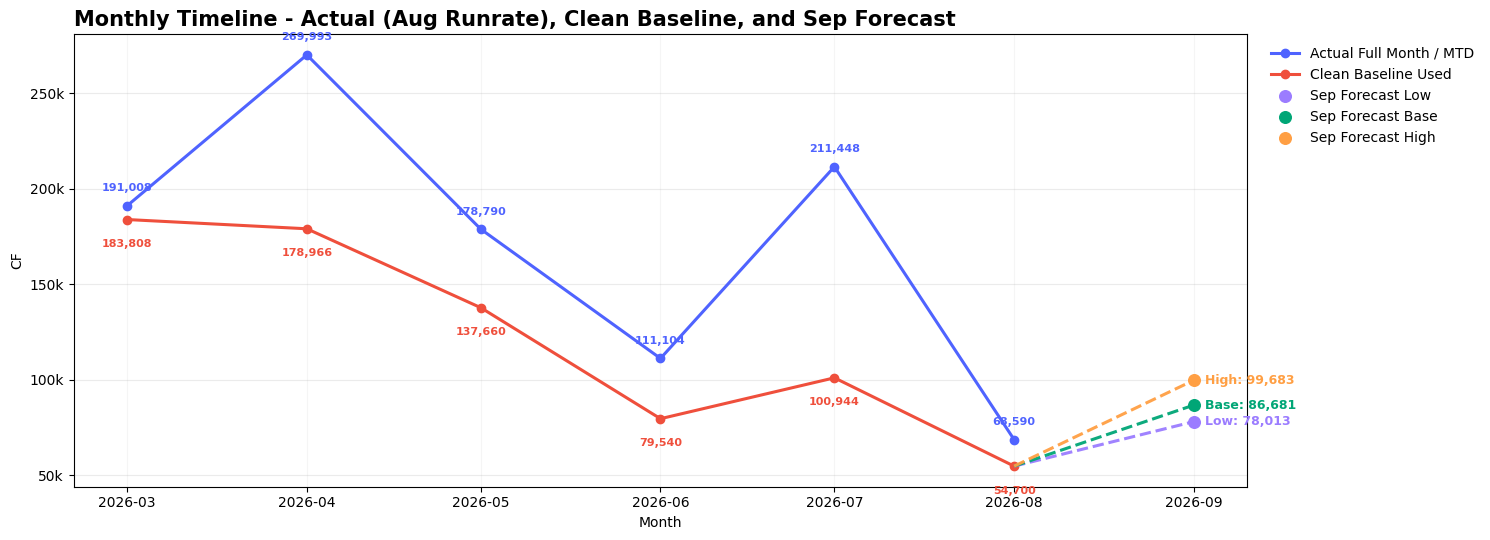

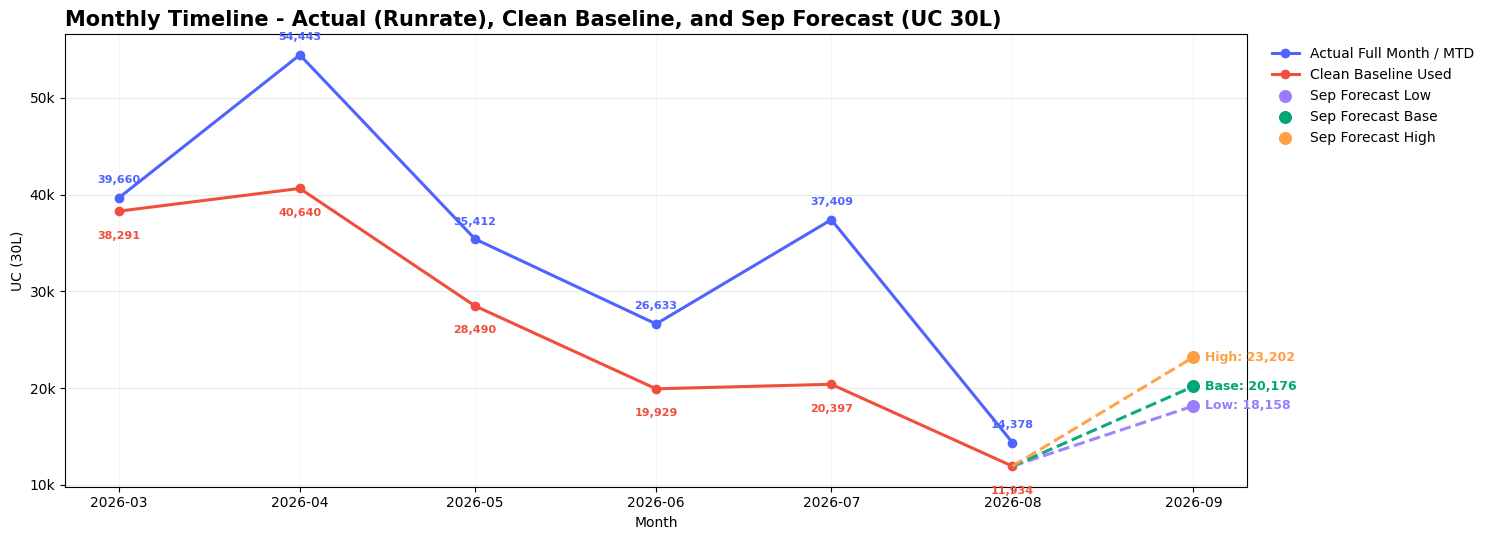

In [ ]:
# ==========================================
# 22. 4. PLOTTING TOTAL TIMELINE (CF & UC)
# ==========================================
actual_total = forecast_monthly_total[forecast_monthly_total["Metric"].eq("Actual Full Month / MTD")].sort_values("Month_Date")
baseline_total = forecast_monthly_total[forecast_monthly_total["Metric"].eq("Clean Baseline Used")].sort_values("Month_Date")

aug_anchor_month = RUNRATE_MONTH
aug_anchor_value = float(baseline_total.loc[baseline_total["Month_Date"].eq(aug_anchor_month), "CF"].sum())
sep_low = float(forecast_detail_sep["Sep Forecast Low"].sum())
sep_base = float(forecast_detail_sep["Sep Forecast Base"].sum())
sep_high = float(forecast_detail_sep["Sep Forecast High"].sum())

if plt is not None:
    fig, ax = plt.subplots(figsize=(15, 5.5))
    ax.plot(actual_total["Month_Date"], actual_total["CF"], marker="o", linewidth=2.2, color="#4f63ff", label="Actual Full Month / MTD")
    ax.plot(baseline_total["Month_Date"], baseline_total["CF"], marker="o", linewidth=2.2, color="#ef4f3c", label="Clean Baseline Used")
    label_series_points(ax, actual_total, "Month_Date", "CF", "#4f63ff", dy=9)
    label_series_points(ax, baseline_total, "Month_Date", "CF", "#ef4f3c", dy=-14)

    forecast_points = [("Low", sep_low, "#9b7cff"), ("Base", sep_base, "#00a676"), ("High", sep_high, "#ff9f43")]
    for label, value, color in forecast_points:
        ax.plot([aug_anchor_month, FORECAST_MONTH], [aug_anchor_value, value], linestyle="--", linewidth=2.2, color=color, alpha=0.95)
        ax.scatter([FORECAST_MONTH], [value], s=70, color=color, zorder=5, label=f"Sep Forecast {label}")
        label_point(ax, FORECAST_MONTH, value, label, color)

    ax.set_title("Monthly Timeline - Actual (Aug Runrate), Clean Baseline, and Sep Forecast", fontsize=15, fontweight="bold", loc="left")
    ax.set_xlabel("Month")
    ax.set_ylabel("CF")
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_k))
    ax.grid(True, axis="y", alpha=0.25)
    ax.grid(True, axis="x", alpha=0.12)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
    plt.tight_layout()
    plt.show()

    actual_total_uc = forecast_monthly_total_uc[forecast_monthly_total_uc["Metric"].eq("Actual Full Month / MTD")].sort_values("Month_Date")
    baseline_total_uc = forecast_monthly_total_uc[forecast_monthly_total_uc["Metric"].eq("Clean Baseline Used")].sort_values("Month_Date")
    aug_anchor_value_uc = float(baseline_total_uc.loc[baseline_total_uc["Month_Date"].eq(aug_anchor_month), "UC"].sum())
    sep_low_uc = float(forecast_range_total_uc["Forecast Low"].iloc[0])
    sep_base_uc = float(forecast_range_total_uc["Forecast Base"].iloc[0])
    sep_high_uc = float(forecast_range_total_uc["Forecast High"].iloc[0])

    fig, ax = plt.subplots(figsize=(15, 5.5))
    ax.plot(actual_total_uc["Month_Date"], actual_total_uc["UC"], marker="o", linewidth=2.2, color="#4f63ff", label="Actual Full Month / MTD")
    ax.plot(baseline_total_uc["Month_Date"], baseline_total_uc["UC"], marker="o", linewidth=2.2, color="#ef4f3c", label="Clean Baseline Used")
    label_series_points(ax, actual_total_uc, "Month_Date", "UC", "#4f63ff", dy=9)
    label_series_points(ax, baseline_total_uc, "Month_Date", "UC", "#ef4f3c", dy=-14)

    forecast_points_uc = [("Low", sep_low_uc, "#9b7cff"), ("Base", sep_base_uc, "#00a676"), ("High", sep_high_uc, "#ff9f43")]
    for label, value, color in forecast_points_uc:
        ax.plot([aug_anchor_month, FORECAST_MONTH], [aug_anchor_value_uc, value], linestyle="--", linewidth=2.2, color=color, alpha=0.95)
        ax.scatter([FORECAST_MONTH], [value], s=70, color=color, zorder=5, label=f"Sep Forecast {label}")
        label_point(ax, FORECAST_MONTH, value, label, color)

    ax.set_title("Monthly Timeline - Actual (Runrate), Clean Baseline, and Sep Forecast (UC 30L)", fontsize=15, fontweight="bold", loc="left")
    ax.set_xlabel("Month")
    ax.set_ylabel("UC (30L)")
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_k))
    ax.grid(True, axis="y", alpha=0.25)
    ax.grid(True, axis="x", alpha=0.12)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
    plt.tight_layout()
    plt.show()
else:
    print("Matplotlib is not available in this runtime; chart tables are displayed instead.")

In [ ]:
# ==========================================
# 22. 5. PACK GROUPING & SKU DATA PREP
# ==========================================
def pack_group_from_sku(sku):
    sku = clean_text(sku)
    if "VOLT" in sku or "200 ML" in sku or "200ML" in sku: return "VOLT / SINGLE SERVE"
    if "350ML" in sku or "350 ML" in sku: return "350 ML"
    if "400ML" in sku or "400 ML" in sku or " 400" in sku: return "400 ML"
    if "3LT" in sku or "3L" in sku or "3 LT" in sku: return "3 LITER"
    if "1LT" in sku or "1 LT" in sku or "1000ML" in sku or "1000 ML" in sku: return "1 LITER"
    return "OTHER"

group_rows = []
for sku, sku_rows in forecast_detail_sep.groupby("SKU Edit"):
    group = pack_group_from_sku(sku)
    sep_value = float(sku_rows["Sep Forecast Base"].sum())
    sep_value_uc = float((sku_rows["Sep Forecast Base"] * sku_rows["UC_Factor"]).sum())
    for month in forecast_input_months:
        mon = month.strftime("%b")
        group_rows.append({
            "Pack Group": group,
            "SKU Edit": sku,
            "Month_Date": month,
            "Month Label": mon,
            "CF": float(sku_rows[f"{mon}_Clean"].sum()),
            "UC": float((sku_rows[f"{mon}_Clean"] * sku_rows["UC_Factor"]).sum()),
            "Point Type": "History",
            "Sep Forecast Base": sep_value,
            "Sep Forecast Base UC": sep_value_uc,
        })
    group_rows.append({
        "Pack Group": group,
        "SKU Edit": sku,
        "Month_Date": FORECAST_MONTH,
        "Month Label": FORECAST_MONTH.strftime("%b"),
        "CF": sep_value,
        "UC": sep_value_uc,
        "Point Type": "Forecast",
        "Sep Forecast Base": sep_value,
        "Sep Forecast Base UC": sep_value_uc,
    })

sku_group_monthly = pd.DataFrame(group_rows)
group_order = (
    sku_group_monthly[sku_group_monthly["Point Type"].eq("Forecast")]
    .groupby("Pack Group", as_index=False)
    .agg(sep_base=("CF", "sum"), sku_count=("SKU Edit", "nunique"))
    .query("sep_base > 0 and `Pack Group` != 'OTHER'")
    .sort_values("sep_base", ascending=False)
)

group_order_uc = (
    sku_group_monthly[sku_group_monthly["Point Type"].eq("Forecast")]
    .groupby("Pack Group", as_index=False)
    .agg(sep_base_uc=("UC", "sum"), sku_count=("SKU Edit", "nunique"))
    .query("sep_base_uc > 0 and `Pack Group` != 'OTHER'")
    .sort_values("sep_base_uc", ascending=False)
)

display(group_order)
display(group_order_uc)
display(sku_group_monthly.head(30))

,Pack Group,sep_base,sku_count
2,350 ML,62933.458333,1
1,3 LITER,16982.664583,3
5,VOLT / SINGLE SERVE,2588.858333,1
0,1 LITER,2327.154167,4
3,400 ML,1848.687500,3


,Pack Group,sep_base_uc,sku_count
1,3 LITER,10189.598750,3
2,350 ML,8810.684167,1
0,1 LITER,465.430833,4
5,VOLT / SINGLE SERVE,414.217333,1
3,400 ML,295.790000,3


,Pack Group,SKU Edit,Month_Date,Month Label,CF,UC,Point Type,Sep Forecast Base,Sep Forecast Base UC
0,400 ML,500040 | BIG COLA 400ML X12,2026-03-01,Mar,5537.0,885.920,History,732.1,117.136
1,400 ML,500040 | BIG COLA 400ML X12,2026-04-01,Apr,1299.0,207.840,History,732.1,117.136
2,400 ML,500040 | BIG COLA 400ML X12,2026-05-01,May,1271.0,203.360,History,732.1,117.136
3,400 ML,500040 | BIG COLA 400ML X12,2026-06-01,Jun,560.0,89.600,History,732.1,117.136
4,400 ML,500040 | BIG COLA 400ML X12,2026-07-01,Jul,765.0,122.400,History,732.1,117.136
5,400 ML,500040 | BIG COLA 400ML X12,2026-08-01,Aug,435.0,69.600,History,732.1,117.136
6,400 ML,500040 | BIG COLA 400ML X12,2026-09-01,Sep,732.1,117.136,Forecast,732.1,117.136
7,OTHER,507563 | BIG MANGO 3100ML X6,2026-03-01,Mar,0.0,0.000,History,0.0,0.000
8,OTHER,507563 | BIG MANGO 3100ML X6,2026-04-01,Apr,0.0,0.000,History,0.0,0.000
9,OTHER,507563 | BIG MANGO 3100ML X6,2026-05-01,May,0.0,0.000,History,0.0,0.000


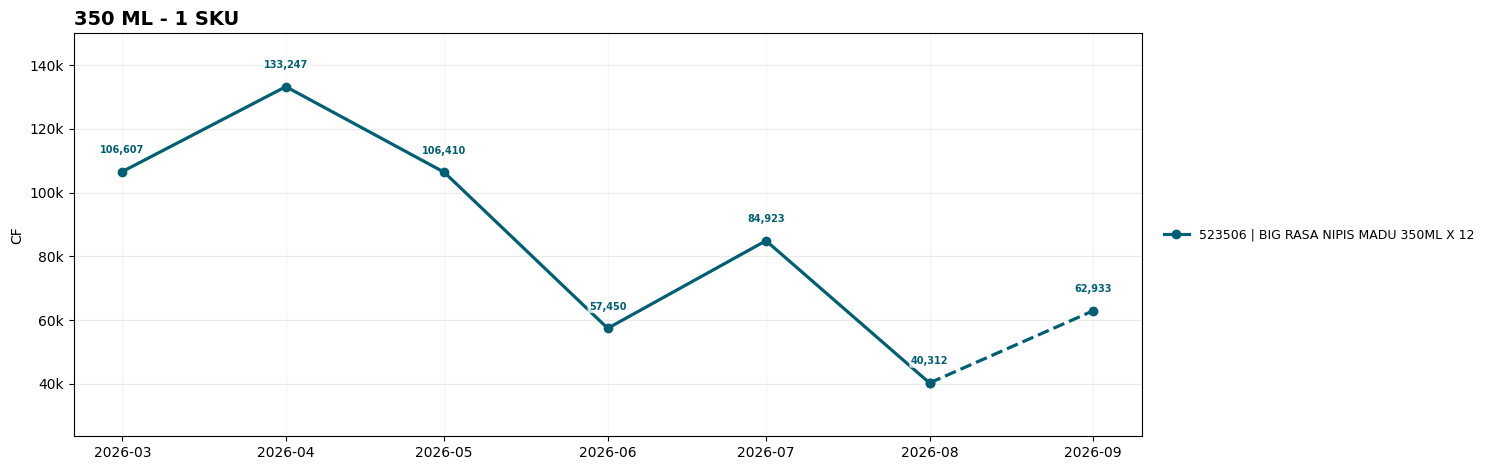

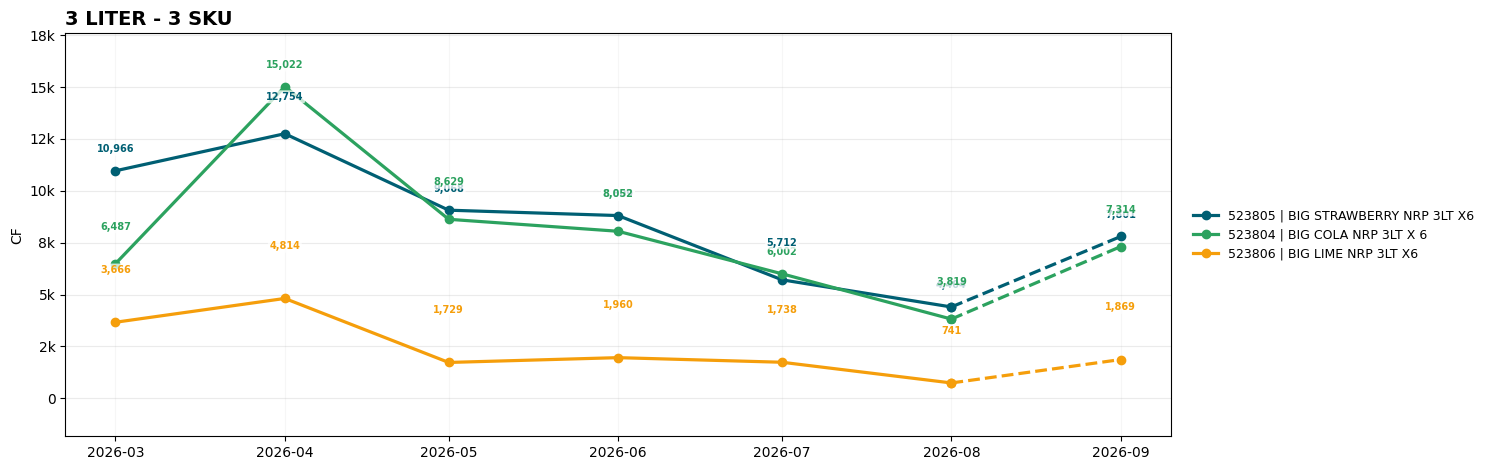

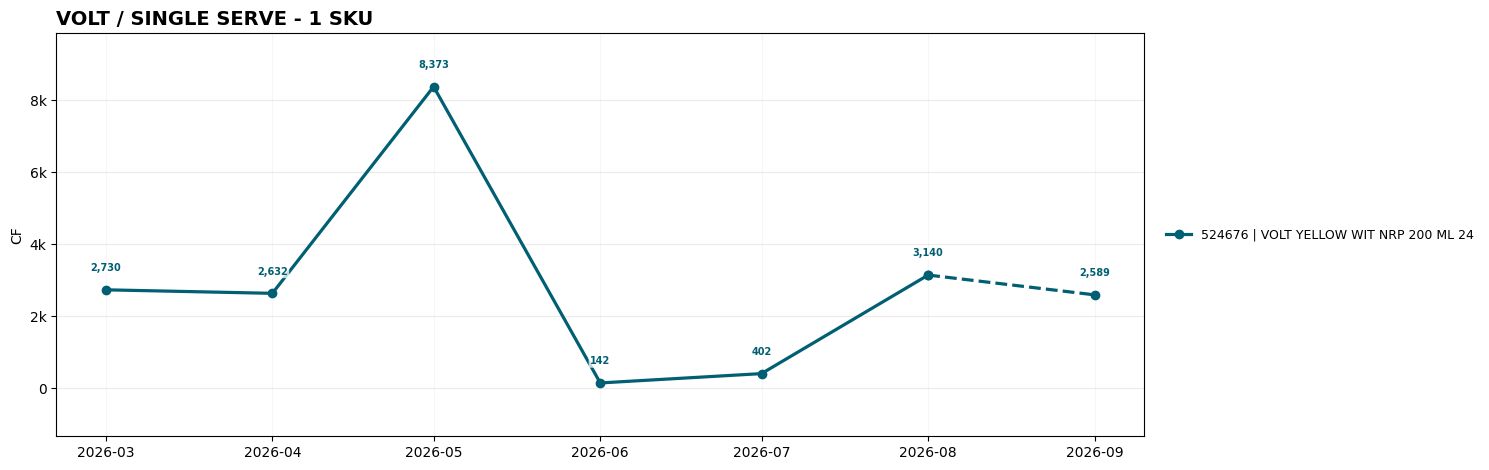

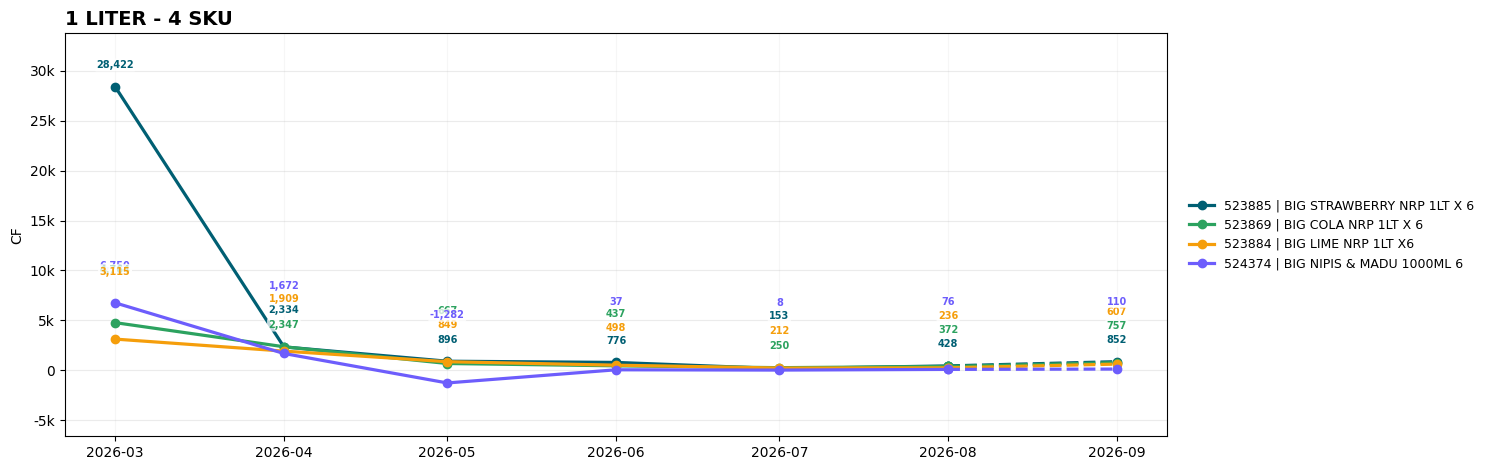

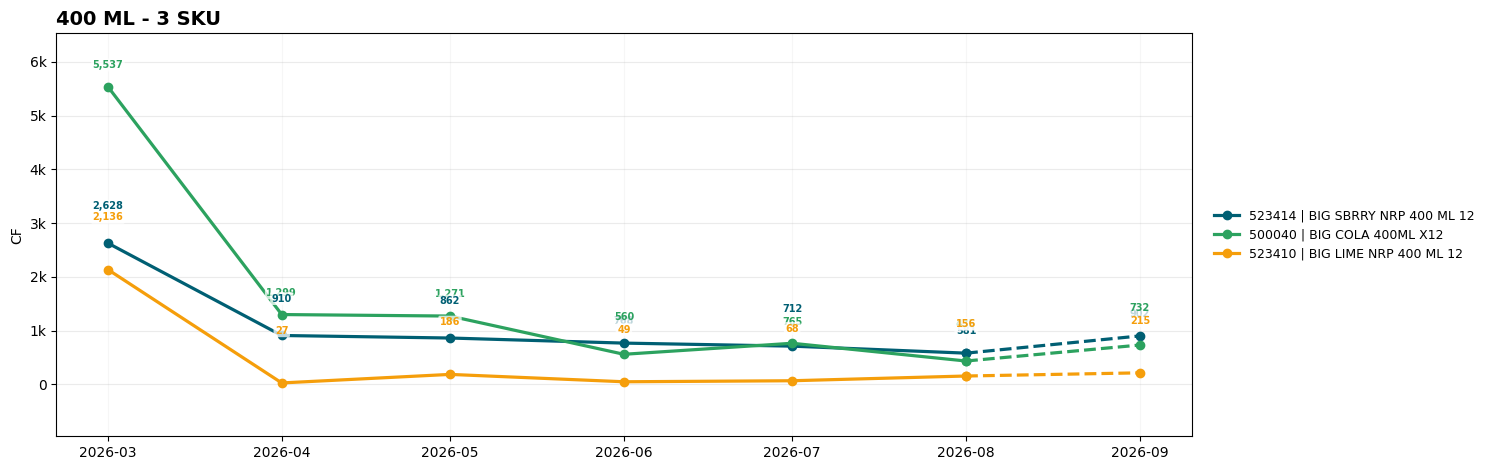

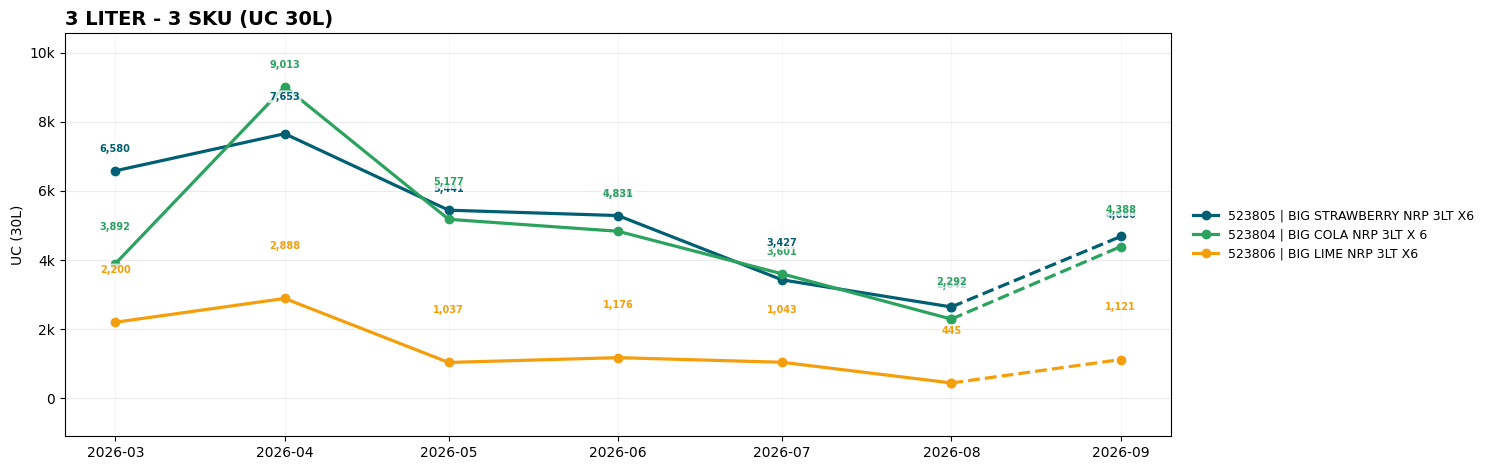

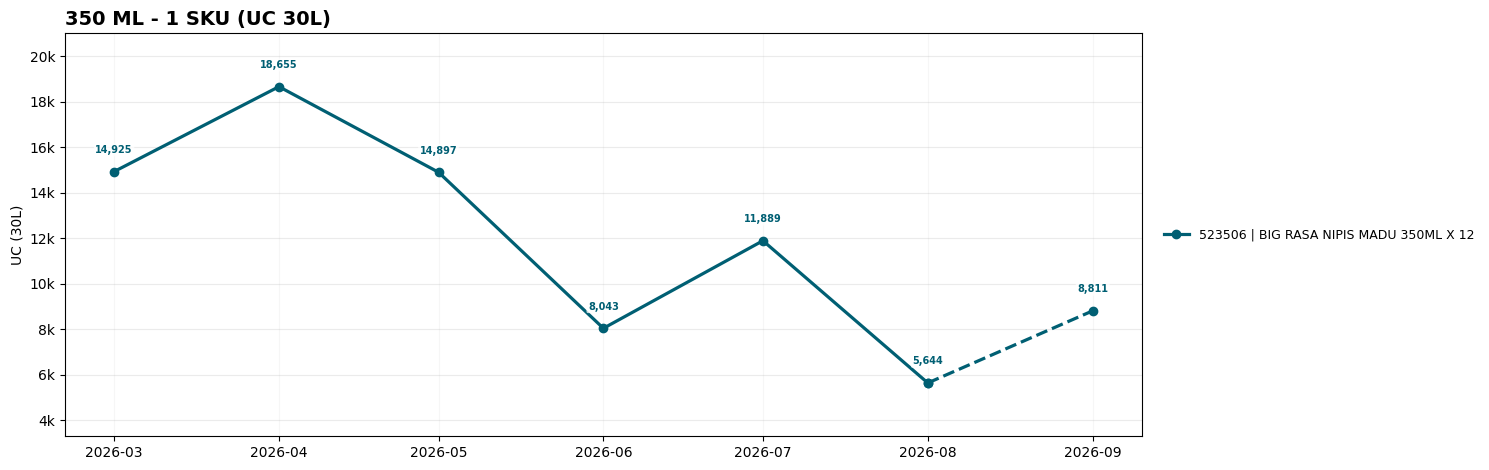

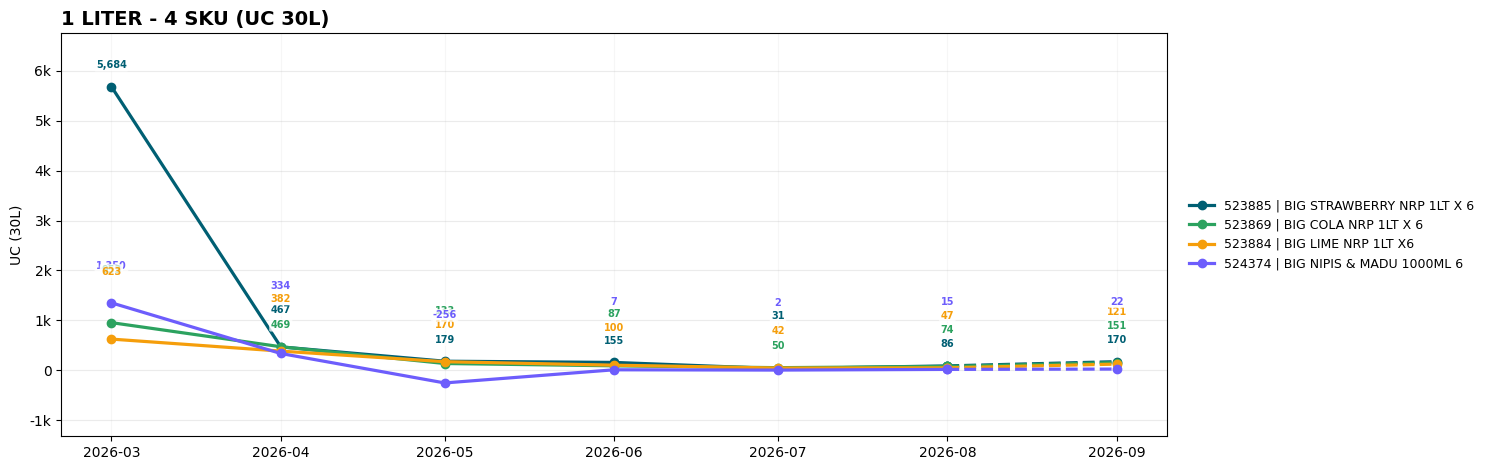

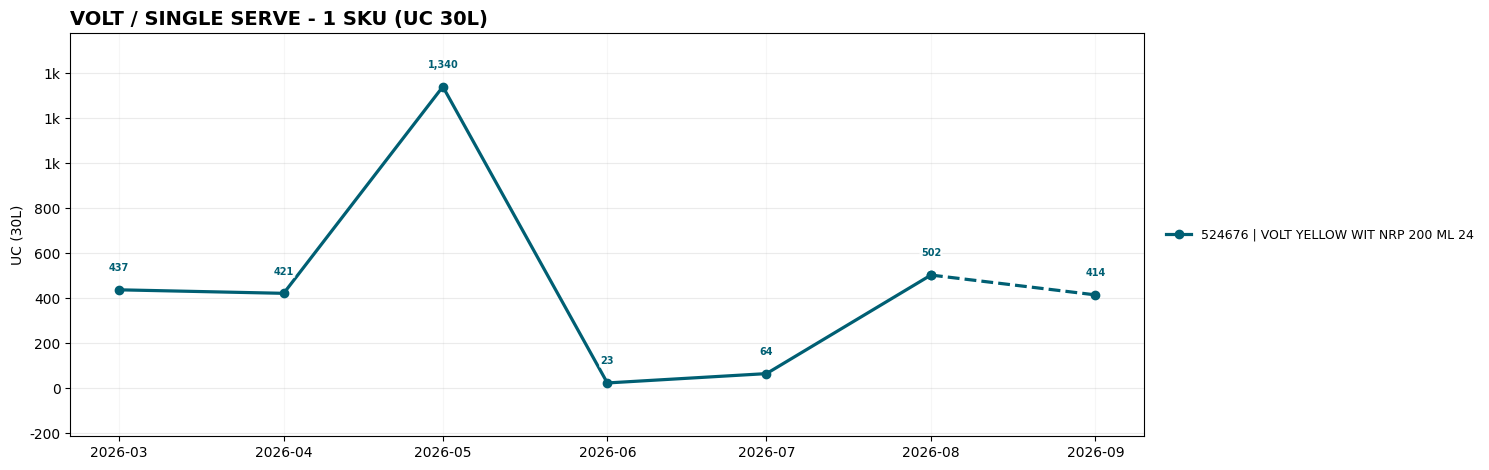

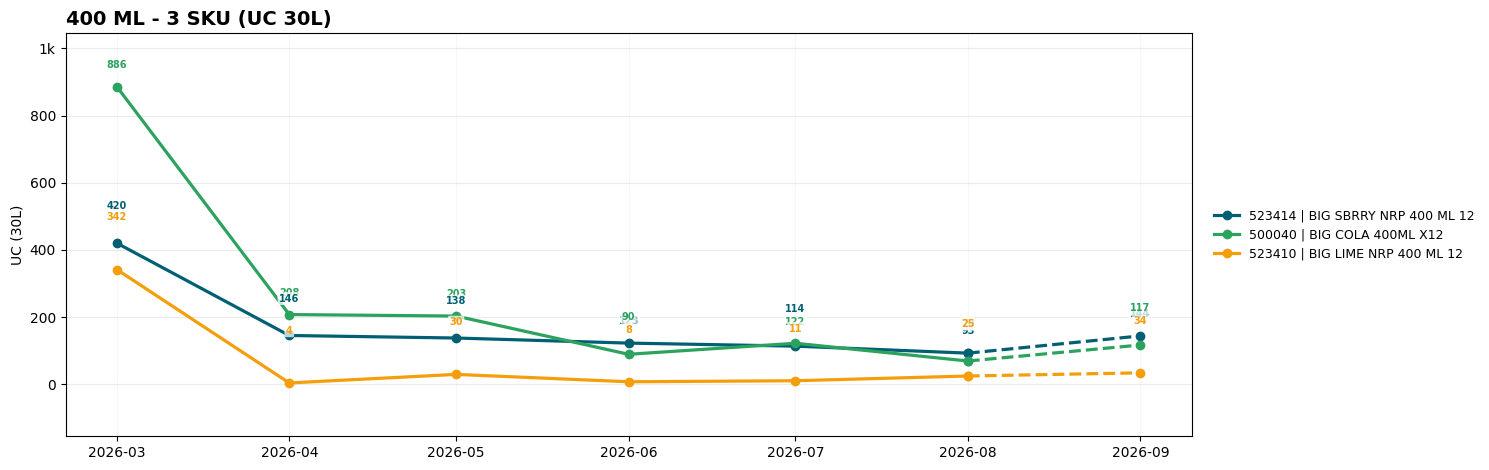

In [ ]:
# ==========================================
# 22. 6. PLOTTING SKU LEVEL CHARTS
# ==========================================
palette = ["#005f73", "#2ca25f", "#f59e0b", "#6d5dfc", "#ef476f", "#118ab2"]

if plt is not None:
    for _, group_row in group_order.iterrows():
        group = group_row["Pack Group"]
        group_data = sku_group_monthly[sku_group_monthly["Pack Group"].eq(group)].copy()
        top_group_skus = (
            group_data[group_data["Point Type"].eq("Forecast")]
            .sort_values("CF", ascending=False)
            .head(5)["SKU Edit"]
            .tolist()
        )
        chart_data = group_data[group_data["SKU Edit"].isin(top_group_skus)]
        color_map = {sku: palette[i % len(palette)] for i, sku in enumerate(top_group_skus)}

        fig, ax = plt.subplots(figsize=(15, 4.8))
        for i, sku in enumerate(top_group_skus):
            sku_data = chart_data[chart_data["SKU Edit"].eq(sku)].sort_values("Month_Date")
            hist = sku_data[sku_data["Point Type"].eq("History")]
            fcst = sku_data[sku_data["Point Type"].eq("Forecast")]
            color = color_map[sku]

            ax.plot(hist["Month_Date"], hist["CF"], marker="o", linewidth=2.3, color=color, label=sku)
            if not hist.empty and not fcst.empty:
                ax.plot(
                    [hist["Month_Date"].max(), FORECAST_MONTH],
                    [float(hist.loc[hist["Month_Date"].idxmax(), "CF"]), float(fcst["CF"].iloc[0])],
                    linestyle="--",
                    marker="o",
                    linewidth=2.3,
                    color=color,
                )

        label_group_points_no_overlap(ax, chart_data, color_map)

        ax.set_title(f"{group} - {len(top_group_skus)} SKU", fontsize=14, fontweight="bold", loc="left")
        ax.set_ylabel("CF")
        ax.yaxis.set_major_formatter(FuncFormatter(fmt_k))
        ax.margins(y=0.18)
        ax.grid(True, axis="y", alpha=0.25)
        ax.grid(True, axis="x", alpha=0.10)
        ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False, fontsize=9)
        plt.tight_layout()
        plt.show()

    for _, group_row in group_order_uc.iterrows():
        group = group_row["Pack Group"]
        group_data = sku_group_monthly[sku_group_monthly["Pack Group"].eq(group)].copy()
        top_group_skus = (
            group_data[group_data["Point Type"].eq("Forecast")]
            .sort_values("UC", ascending=False)
            .head(5)["SKU Edit"]
            .tolist()
        )
        chart_data = group_data[group_data["SKU Edit"].isin(top_group_skus)]
        color_map = {sku: palette[i % len(palette)] for i, sku in enumerate(top_group_skus)}

        fig, ax = plt.subplots(figsize=(15, 4.8))
        for i, sku in enumerate(top_group_skus):
            sku_data = chart_data[chart_data["SKU Edit"].eq(sku)].sort_values("Month_Date")
            hist = sku_data[sku_data["Point Type"].eq("History")]
            fcst = sku_data[sku_data["Point Type"].eq("Forecast")]
            color = color_map[sku]

            ax.plot(hist["Month_Date"], hist["UC"], marker="o", linewidth=2.3, color=color, label=sku)
            if not hist.empty and not fcst.empty:
                ax.plot(
                    [hist["Month_Date"].max(), FORECAST_MONTH],
                    [float(hist.loc[hist["Month_Date"].idxmax(), "UC"]), float(fcst["UC"].iloc[0])],
                    linestyle="--",
                    marker="o",
                    linewidth=2.3,
                    color=color,
                )

        label_group_points_no_overlap(ax, chart_data, color_map, y_col="UC")

        ax.set_title(f"{group} - {len(top_group_skus)} SKU (UC 30L)", fontsize=14, fontweight="bold", loc="left")
        ax.set_ylabel("UC (30L)")
        ax.yaxis.set_major_formatter(FuncFormatter(fmt_k))
        ax.margins(y=0.18)
        ax.grid(True, axis="y", alpha=0.25)
        ax.grid(True, axis="x", alpha=0.10)
        ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False, fontsize=9)
        plt.tight_layout()
        plt.show()

## 22. Export Forecast CSV

File CSV akan disimpan di folder `forecast_output` pada folder yang sama dengan file dashboard di Google Drive.

In [ ]:
# ==========================================
# 23. 1. SETUP & DIRECTORY CREATION
# ==========================================
# Menyiapkan direktori penyimpanan file ekspor di Google Drive dan daftar SKU yang dikecualikan.

EXPORT_DIR = DRIVE_SALES_FILE.parent / "forecast_output"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
forecast_label = FORECAST_MONTH.strftime("%Y_%m")

# SKU yang dikecualikan sesuai permintaan pengguna.
excluded_skus = ['507563', '522635', '522636', '523229', '523415']

In [ ]:
# ==========================================
# 23. 2. PREPARASI DATA TRANSAKSI (FILE 01)
# ==========================================
# Menerapkan filter eksklusi SKU pada data sumber transaksi aktual.

order_clean_adjusted = forecast_source[
    ~forecast_source['Item Code Edit'].isin(excluded_skus)
][[
    "Source Sheet", "Year", "Month No", "Date",
    "Channel Group", "Original Customer Name", "Customer Name", "Original Branch", "Branch", "Channel", "Cust Code",
    "Short Item Description Real", "Item Code Real",
    "Short Item Description Edit", "Item Code Edit",
    "Format", "Box Content", "Reference Format", "Reference Box Content",
    "CF Real", "CF Edit", "CF Adjustment",
    "Group Key", "SKU Real", "SKU Edit", "Real != Edit",
]].copy()

In [ ]:
# ==========================================
# 23. 3. SKELETON FULL MATRIX (CROSS JOIN)
# ==========================================
# Membuat kombinasi lengkap (cross join) antara daftar customer dan SKU aktif.

cust_list = forecast_source[['Cust Code', 'Customer Name', 'Branch', 'Channel Group']].drop_duplicates('Cust Code')

sku_list = forecast_source[
    ~forecast_source['Item Code Edit'].isin(excluded_skus)
][['Item Code Edit', 'Short Item Description Edit', 'SKU Edit']].drop_duplicates('SKU Edit')

skeleton = cust_list.assign(key=1).merge(sku_list.assign(key=1), on='key').drop('key', axis=1)

In [ ]:
# ==========================================
# 23. 4. PIVOT DATA AKTUAL 2026
# ==========================================
# Membentuk pivot table bulanan untuk seluruh transaksi aktual tahun 2026.

export_months = pd.date_range("2026-01-01", "2026-12-01", freq="MS")
export_month_labels = [m.strftime("%b_Actual") for m in export_months]

actual_2026_pivot = (
    monthly_customer_sku[
        monthly_customer_sku["Month"].dt.year.eq(2026) &
        ~monthly_customer_sku['Item Code Edit'].isin(excluded_skus)
    ]
    .pivot_table(index=key_cols, columns="Month", values="CF", aggfunc="sum", fill_value=0)
    .reset_index()
)

for month in export_months:
    if month not in actual_2026_pivot.columns:
        actual_2026_pivot[month] = 0

actual_2026_pivot = actual_2026_pivot[key_cols + list(export_months)].rename(
    columns={month: label for month, label in zip(export_months, export_month_labels)}
)

In [ ]:
# ==========================================
# 23. 5. GABUNGKAN SKELETON DENGAN FORECAST
# ==========================================
# Menggabungkan rangka matriks dengan data kalkulasi forecast dan pivot bulanan.

forecast_calc_cols = [
    "Mar_Clean", "Apr_Clean", "May_Clean", "Jun_Clean", "Aug_Clean",
    "Aug_MTD", "Aug_RunRate", "Aug_Clean_RunRate",
    "Promo_Suspect_Months", "Promo_Suspect_Uplift",
    "Active Months", "Inactive 3M Rule", "Volatility", "Demand Class",
    "Sep Forecast Base", "Sep Forecast Low", "Sep Forecast High",
    "UC_Factor", "Sep Forecast Base UC"
]

forecast_detail_filtered = forecast_detail_sep[
    ~forecast_detail_sep['Item Code Edit'].isin(excluded_skus)
].copy()

full_matrix_data = skeleton.merge(forecast_detail_filtered[key_cols + forecast_calc_cols], on=key_cols, how='left')
full_matrix_data = full_matrix_data.merge(actual_2026_pivot[key_cols + export_month_labels], on=key_cols, how='left')

# Penanganan nilai kosong (NaN) setelah penggabungan matriks.
full_matrix_data['Demand Class'] = full_matrix_data['Demand Class'].fillna("No History")
full_matrix_data[export_month_labels] = full_matrix_data[export_month_labels].fillna(0)
numeric_cols = [c for c in full_matrix_data.columns if 'Forecast' in c or 'Clean' in c or 'Uplift' in c or 'UC' in c]
full_matrix_data[numeric_cols] = full_matrix_data[numeric_cols].fillna(0)

In [ ]:
# ==========================================
# 23. 6. EKSPOR KE FILE CSV
# ==========================================
# Memisahkan dataframe final menjadi 3 file terpisah dan menyimpannya ke direktori tujuan.

pivot_full_export = full_matrix_data[key_cols + export_month_labels + forecast_calc_cols].copy()

forecast_sep_full = full_matrix_data[[
    "Channel Group", "Branch", "Cust Code", "Customer Name",
    "Item Code Edit", "Short Item Description Edit", "SKU Edit",
    "Demand Class", "Inactive 3M Rule", "UC_Factor",
    "Sep Forecast Low", "Sep Forecast Base", "Sep Forecast High",
    "Sep Forecast Base UC"
]].copy()
forecast_sep_full.insert(0, "Forecast Month", FORECAST_MONTH.strftime("%Y-%m"))

export_files = {
    f"01_order_clean_adjusted_{forecast_label}_modern.csv": order_clean_adjusted,
    f"02_pivot_customer_sku_full_matrix_{forecast_label}_modern.csv": pivot_full_export,
    f"03_forecast_sep_full_matrix_{forecast_label}_modern.csv": forecast_sep_full,
}

exported_paths = []
for filename, dataframe in export_files.items():
    output_path = EXPORT_DIR / filename
    dataframe.to_csv(output_path, index=False, encoding="utf-8-sig")
    exported_paths.append(str(output_path))

print("Export folder:", EXPORT_DIR)
print(f"Rows in Full Matrix (Excluding {len(excluded_skus)} SKU types): {len(full_matrix_data)}")
print("Exported CSV files:")
for path in exported_paths:
    print("-", path)

Export folder: /content/drive/MyDrive/Data Sales/forecast_output
Rows in Full Matrix (Excluding 5 SKU types): 3096
Exported CSV files:
- /content/drive/MyDrive/Data Sales/forecast_output/01_order_clean_adjusted_2026_09_modern.csv
- /content/drive/MyDrive/Data Sales/forecast_output/02_pivot_customer_sku_full_matrix_2026_09_modern.csv
- /content/drive/MyDrive/Data Sales/forecast_output/03_forecast_sep_full_matrix_2026_09_modern.csv


### Audit Khusus: Bali & Pekanbaru
Sel ini bertujuan untuk melacak apakah volume historis dari area Bali dan Pekanbaru tertangkap dalam perhitungan, meskipun ada perubahan nama branch.

In [ ]:
# ==========================================
# 24. 1. AREA AUDIT BALI & PEKANBARU
# ==========================================
# Memeriksa volume transaksi dan status customer pada area ekspansi Bali dan Pekanbaru.

area_keywords = ['BALI', 'PEKANBARU']

# Mencari data transaksi pada branch atau customer yang mengandung kata kunci area.
area_audit = sales_aligned_append[
    sales_aligned_append['Branch'].str.contains('|'.join(area_keywords), case=False, na=False) |
    sales_aligned_append['Customer Name'].str.contains('|'.join(area_keywords), case=False, na=False)
].copy()

# Membuat ringkasan volume (CF Edit) per Branch dan Bulan.
area_summary = area_audit.groupby(['Branch', 'Month']).agg(CF=('CF Edit', 'sum')).reset_index()
area_summary = area_summary.pivot(index='Branch', columns='Month', values='CF').fillna(0)

print("Ringkasan Volume di Branch terkait Bali/Pekanbaru:")
display(area_summary)

Ringkasan Volume di Branch terkait Bali/Pekanbaru:


Month,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01
Branch,,,,,,,,,,,,,,,,,,,,
CEDIS MT SURABAYA,550.0,831.0,200.0,1279.0,438.0,247.0,3063.0,654.0,2868.0,2583.0,2530.0,3569.0,751.0,274.0,272.0,1607.0,3801.0,4067.0,0.0,0.0
FACTORY,3882.0,997.0,3350.0,722.0,-3.0,2102.0,8441.0,16433.0,18226.0,19015.0,3027.0,32912.0,2877.0,7555.5,13734.0,12896.0,9806.5,7656.0,3966.0,0.0
LOGISTIC PROVIDER BALI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9047.0,1518.0
LOGISTIC PROVIDER BEKASI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,0.0,0.0
LOGISTIC PROVIDER PEKANBARU,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,170.0,554.0,380.0,0.0,0.0,0.0,348.0,2613.0
